# Skin Lesion Classification — DenseNet121 + Attention Block + Clinical MLP (TensorFlow)

**Everything is in this notebook** — no other project files are needed. Run the cells top to bottom.

```
Image ─► Preprocessing ─► DenseNet121 (ImageNet) ─► Attention Block ─► GAP ──┐
                             7×7×1024                 7×7×1024          1024  ├─► Concat ─► Dense(256) ─► FC(7, softmax)
Clinical data (age, sex, localization) ─► MLP (128 → 64) ─────────────────── 64 ──┘
```

**Attention Block** (input F = H×W×C):

| Path | Operation | Output |
|---|---|---|
| 1 | Conv 1×1 (C → 1) | H×W×1 |
| 2 | Max-pool across channels | H×W×1 |
| 3 | Avg-pool across channels = A (H×W×1) → reshape 1×HW → sigmoid → reshape back = gate → **A ⊗ gate** | H×W×1 |
| fuse | Concat → H×W×3 → Conv 1×1 → sigmoid = attention map M | H×W×1 |
| out | F ⊗ M (broadcast over channels) | H×W×C |

**Notebook layout:** 1–9 setup and model code · 10 quick test · 11 comparison models 1–6 · 12 proposed model (model 7) · 13 optional seeds and 13b MobileNetV2 · 14–15 attention maps and prediction · 16–21 paper tables and figures.

**GPU note (Windows):** TensorFlow ≥ 2.11 has no GPU support on native Windows. Use a **Python 3.10** environment with **TensorFlow 2.10** (setup in section 0), or WSL2. The code works on TF 2.10 (Keras 2) and TF 2.16+ (Keras 3).

## 0. One-time environment setup (run in a terminal / Anaconda Prompt, not here)

```bash
conda create -n skin python=3.10 -y
conda activate skin
conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0 -y
pip install "tensorflow==2.10.1" "numpy<2" pandas scikit-learn matplotlib notebook ipykernel
python -m ipykernel install --user --name skin --display-name "Python (skin)"
```
Then open this notebook and choose the kernel **Python (skin)**.

## 1. Imports and GPU check

In [2]:
import os, gc, json, time, random, glob, sys

# --- Windows GPU fix -----------------------------------------------------------------
# TensorFlow 2.10 needs the CUDA/cuDNN DLLs that conda installed in <env>\Library\bin.
# Windows only finds them when the environment is *activated*. If Jupyter was started from
# another environment (e.g. base) and only the kernel is "Python (skin)", they are not found
# and TensorFlow silently uses the CPU. Adding the folder here, BEFORE importing TensorFlow, fixes that.
if os.name == "nt":
    _dll_dir = os.path.join(sys.prefix, "Library", "bin")
    if os.path.isdir(_dll_dir):
        os.environ["PATH"] = _dll_dir + os.pathsep + os.environ.get("PATH", "")
        os.add_dll_directory(_dll_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, f1_score,
                             confusion_matrix, precision_recall_fscore_support, roc_auc_score)

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
GPUS = tf.config.list_physical_devices("GPU")
for g in GPUS:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError:
        pass
print("GPU:", GPUS if GPUS else "NONE -> running on CPU (slow). See the check printed below.")


def gpu_info():
    """Print the GPU name, memory, driver and the CUDA/cuDNN versions TensorFlow uses."""
    import subprocess
    for i, g in enumerate(GPUS):
        d = tf.config.experimental.get_device_details(g)
        cc = d.get("compute_capability")
        print(f"GPU {i}: {d.get('device_name', '?')}" + (f" | compute capability {cc[0]}.{cc[1]}" if cc else ""))
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=memory.total,memory.used,driver_version,"
                              "temperature.gpu,utilization.gpu", "--format=csv,noheader"],
                             capture_output=True, text=True, timeout=15).stdout.strip()
        for line in out.splitlines():
            total, used, driver, temp, util = [x.strip() for x in line.split(",")]
            print(f"       memory: {used} used of {total} | driver {driver} | {temp} °C | utilisation {util}")
    except Exception as e:
        print("       (nvidia-smi not available:", e, ")")
    b = tf.sysconfig.get_build_info()

    def _ver(v):                      # Windows builds report e.g. "64_112" -> "11.2", "64_8" -> "8"
        v = str(v or "?").replace("64_", "")
        return f"{v[:-1]}.{v[-1]}" if v.isdigit() and len(v) == 3 else v
    print(f"       TensorFlow built for CUDA {_ver(b.get('cuda_version'))}, cuDNN {_ver(b.get('cudnn_version'))}")


def gpu_peak_memory_gb():
    """Peak GPU memory TensorFlow used since the last reset (None on CPU)."""
    try:
        return tf.config.experimental.get_memory_info("GPU:0")["peak"] / 1024 ** 3
    except Exception:
        return None


if GPUS:
    gpu_info()

if not GPUS:   # explain why
    print("\n--- GPU check ---")
    print("Python is in the 'skin' environment:", "skin" in sys.prefix.lower(), "->", sys.prefix)
    print("TensorFlow built with CUDA         :", tf.test.is_built_with_cuda(),
          "(False = CPU-only TensorFlow; install tensorflow==2.10.1)")
    if os.name == "nt":
        for dll in ["cudart64_110.dll", "cublas64_11.dll", "cudnn64_8.dll"]:
            print(f"{dll:20s} found in env          :", os.path.exists(os.path.join(sys.prefix, "Library", "bin", dll)))
        print("If a DLL is False -> in Anaconda Prompt run:  conda activate skin")
        print("                     conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0 -y")
        print("If all are True   -> check the NVIDIA driver (run nvidia-smi), plug in the charger, restart the kernel.")

# Keras 3 saves weights as .weights.h5; Keras 2 (TF 2.10) uses the TF-checkpoint format, because its .h5
# weight order changes when layers are frozen/unfrozen.
KERAS3 = int(keras.__version__.split(".")[0]) >= 3

Python: C:\Users\Dilip Prajapati\.conda\envs\skin\python.exe
TensorFlow: 2.10.1 | Keras: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU 0: NVIDIA GeForce RTX 3050 6GB Laptop GPU | compute capability 8.6
       memory: 60 MiB used of 6144 MiB | driver 581.86 | 46 °C | utilisation 0 %
       TensorFlow built for CUDA 11.2, cuDNN 8


## 2. Configuration — **edit `DATA_ROOT`**

In [3]:
# Folder containing HAM10000_metadata.csv, HAM10000_images_part_1/, HAM10000_images_part_2/
DATA_ROOT = r"C:\Users\Dilip Prajapati\Desktop\MInor Project_Skin\Dataset\Data"   # <-- EDIT

METADATA_CSV = os.path.join(DATA_ROOT, "HAM10000_metadata.csv")
IMAGE_DIRS = [os.path.join(DATA_ROOT, "HAM10000_images_part_1"),
              os.path.join(DATA_ROOT, "HAM10000_images_part_2")]
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 224                 # DenseNet121 native resolution, fits 6 GB VRAM

# Split mode:
#   "strict" -> 70/15/15 split grouped by lesion_id (no lesion in two splits), dx_type excluded
#   "paper"  -> 70/30 image-level split, no validation set, dx_type included (inflated numbers)
SPLIT_MODE = "strict"
USE_DX_TYPE = SPLIT_MODE == "paper"
TRAIN_FRAC = 0.70
VAL_FRAC = 0.0 if SPLIT_MODE == "paper" else 0.15
TEST_FRAC = 0.30 if SPLIT_MODE == "paper" else 0.15
SEED = 42

# Class imbalance: "oversample" (equal images per class each epoch) | "class_weight" | "none"
BALANCE_STRATEGY = "oversample"   # run A1 with "oversample", then A2 with "class_weight"
TARGET_PER_CLASS = 2000        # 7 x 2000 = 14,000 training images per epoch

# Model
CLINICAL_MLP_UNITS = (128, 64)
FUSION_UNITS = 256
DROPOUT = 0.4

# Training (tuned for RTX 3050 6 GB)
BATCH_SIZE = 16                # lower to 8 if you get out-of-memory
WARMUP_EPOCHS = 5              # phase 1: backbone frozen
LR_SCHEDULE = "fixed"          # "fixed" = constant LR in each stage; "plateau" = reduce x0.3 when val_loss stalls 3 epochs
WARMUP_LR = 1e-3               # stage 1 (backbone frozen)
FINE_TUNE_EPOCHS = 95          # phase 2: fine-tune backbone -> total 5 + 95 = up to 100 epochs
FINE_TUNE_LR = 1e-4            # stage 2 (fine-tuning), fixed
FINE_TUNE_LAYERS = 150         # last N DenseNet layers unfrozen (None = all)
EARLY_STOP_PATIENCE = 15       # stop if val_loss does not improve for 15 epochs (best checkpoint kept)
LABEL_SMOOTHING = 0.05
USE_MIXED_PRECISION = True     # float16 compute on GPU
CACHE_IMAGES_IN_RAM = False    # True = faster epochs after the first (~1.5 GB RAM)

# results folder is named after the settings, so runs with different settings never mix
OUTPUT_DIR = f"outputs_{SPLIT_MODE}_{BALANCE_STRATEGY}_{LR_SCHEDULE}lr"   # e.g. outputs_strict_oversample_fixedlr

tf.keras.utils.set_random_seed(SEED)
if GPUS and USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision ON")

assert os.path.exists(METADATA_CSV), f"Not found: {METADATA_CSV} -- fix DATA_ROOT"
for d in IMAGE_DIRS:
    print(d, "->", len(os.listdir(d)) if os.path.isdir(d) else "MISSING", "files")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
Mixed precision ON
C:\Users\Dilip Prajapati\Desktop\MInor Project_Skin\Dataset\Data\HAM10000_images_part_1 -> 5000 files
C:\Users\Dilip Prajapati\Desktop\MInor Project_Skin\Dataset\Data\HAM10000_images_part_2 -> 5015 files


## 3. Load metadata and split
`strict` mode splits by **lesion_id** so the same lesion never appears in both train and test.

In [4]:
def load_and_split_metadata():
    df = pd.read_csv(METADATA_CSV)
    if SPLIT_MODE == "paper":
        tr, te = train_test_split(df, train_size=TRAIN_FRAC, stratify=df["dx"], random_state=SEED)
        return tr.reset_index(drop=True), None, te.reset_index(drop=True)
    lesions = df.drop_duplicates(subset="lesion_id")[["lesion_id", "dx"]]
    tr_l, tmp_l = train_test_split(lesions, train_size=TRAIN_FRAC, stratify=lesions["dx"],
                                   random_state=SEED)
    va_l, te_l = train_test_split(tmp_l, train_size=VAL_FRAC / (VAL_FRAC + TEST_FRAC),
                                  stratify=tmp_l["dx"], random_state=SEED)
    pick = lambda ids: df[df.lesion_id.isin(ids.lesion_id)].reset_index(drop=True)
    return pick(tr_l), pick(va_l), pick(te_l)


train_df, val_df, test_df = load_and_split_metadata()
print(f"train {len(train_df)} | val {0 if val_df is None else len(val_df)} | test {len(test_df)}")
pd.DataFrame({s: d["dx"].value_counts() for s, d in
              [("train", train_df), ("val", val_df), ("test", test_df)] if d is not None})

train 7002 | val 1532 | test 1481


,train,val,test
dx,,,
akiec,230,51,46
bcc,366,77,71
bkl,774,157,168
df,76,19,20
mel,778,170,165
nv,4679,1034,992
vasc,99,24,19


## 4. Clinical features (the "Clinical data" input)
age → median-imputed + standardised; sex, localization → one-hot ("unknown" = missing → mode).
All statistics are fitted on **train only**.

In [5]:
CAT_COLS = ["sex", "localization"] + (["dx_type"] if USE_DX_TYPE else [])


def fit_clinical_encoder(df):
    enc = {"age_median": float(df["age"].median()), "categories": {}, "modes": {}}
    age = df["age"].fillna(enc["age_median"])
    enc["age_mean"], enc["age_std"] = float(age.mean()), float(age.std() or 1.0)
    for col in CAT_COLS:
        vals = df[col].replace("unknown", np.nan)
        enc["modes"][col] = str(vals.mode()[0])
        enc["categories"][col] = sorted(vals.fillna(enc["modes"][col]).astype(str).unique())
    enc["feature_names"] = ["age"] + [f"{c}_{v}" for c in CAT_COLS for v in enc["categories"][c]]
    return enc


def transform_clinical(df, enc):
    age = df["age"].fillna(enc["age_median"]).to_numpy(dtype=np.float32)
    parts = [((age - enc["age_mean"]) / enc["age_std"])[:, None]]
    for col, cats in enc["categories"].items():
        vals = df[col].replace("unknown", np.nan).fillna(enc["modes"][col]).astype(str)
        idx = {c: i for i, c in enumerate(cats)}
        onehot = np.zeros((len(df), len(cats)), dtype=np.float32)
        for r, v in enumerate(vals):
            if v in idx:
                onehot[r, idx[v]] = 1.0
        parts.append(onehot)
    return np.concatenate(parts, axis=1).astype(np.float32)


def labels_of(df):
    m = {c: i for i, c in enumerate(CLASS_NAMES)}
    return df["dx"].map(m).to_numpy(dtype=np.int32)


encoder = fit_clinical_encoder(train_df)
X_clin = {"train": transform_clinical(train_df, encoder), "test": transform_clinical(test_df, encoder)}
Y = {"train": labels_of(train_df), "test": labels_of(test_df)}
if val_df is not None:
    X_clin["val"], Y["val"] = transform_clinical(val_df, encoder), labels_of(val_df)
CLINICAL_DIM = X_clin["train"].shape[1]
print(CLINICAL_DIM, "clinical features:", encoder["feature_names"])

17 clinical features: ['age', 'sex_female', 'sex_male', 'localization_abdomen', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_upper extremity']


## 5. Image pipeline (tf.data) + augmentation + class balancing
In `oversample` mode each class gets its own shuffled, repeating stream, sampled with equal
probability — so every epoch sees ~`TARGET_PER_CLASS` images per class, with a fresh random
augmentation on every repeat.

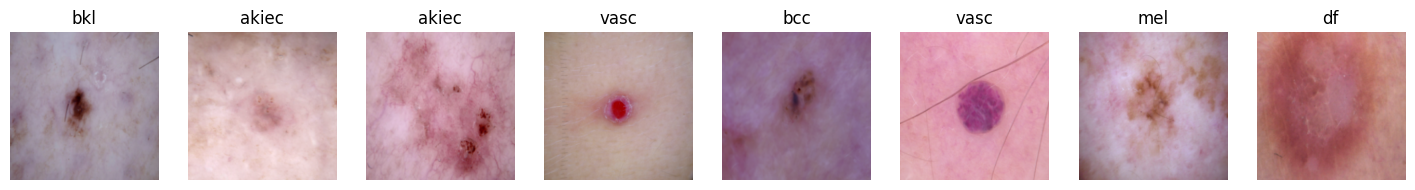

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

lookup = {}
for d in IMAGE_DIRS:
    for f in (os.listdir(d) if os.path.isdir(d) else []):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            lookup[os.path.splitext(f)[0]] = os.path.join(d, f)


def image_paths_for(df):
    missing = [i for i in df["image_id"] if i not in lookup]
    if missing:
        raise FileNotFoundError(f"{len(missing)} images missing, e.g. {missing[:3]}")
    return np.array([lookup[i] for i in df["image_id"]])


PATHS = {"train": image_paths_for(train_df), "test": image_paths_for(test_df)}
if val_df is not None:
    PATHS["val"] = image_paths_for(val_df)


def load_image(path, size=IMG_SIZE):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, (size, size), antialias=True)
    return tf.cast(img, tf.float32)                 # 0..255; normalised inside the model


def augment(img):
    size = tf.shape(img)[0]
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    crop = tf.cast(tf.cast(size, tf.float32) * tf.random.uniform([], 0.80, 1.0), tf.int32)
    img = tf.image.random_crop(img, tf.stack([crop, crop, 3]))     # random zoom
    img = tf.image.resize(img, tf.stack([size, size]))
    img = img / 255.0
    img = tf.image.random_brightness(img, 0.10)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.random_saturation(img, 0.9, 1.1)
    img = tf.image.random_hue(img, 0.02)
    return tf.clip_by_value(img, 0.0, 1.0) * 255.0


def _base_ds(paths, clin, labels, load_images=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, clin, tf.one_hot(labels, NUM_CLASSES)))
    def _load(p, c, y):
        img = load_image(p) if load_images else tf.zeros((IMG_SIZE, IMG_SIZE, 3))
        return img, c, y
    return ds.map(_load, num_parallel_calls=AUTOTUNE)


def _to_inputs(img, c, y):
    return {"image": img, "clinical": c}, y


def make_eval_ds(split, batch_size=BATCH_SIZE, load_images=True):
    ds = _base_ds(PATHS[split], X_clin[split], Y[split], load_images)
    if CACHE_IMAGES_IN_RAM:
        ds = ds.cache()
    return ds.map(_to_inputs).batch(batch_size).prefetch(AUTOTUNE)


def make_train_ds(batch_size=BATCH_SIZE, load_images=True, seed=SEED):
    paths, clin, labels = PATHS["train"], X_clin["train"], Y["train"]
    if BALANCE_STRATEGY == "oversample":
        streams = []
        for k in range(NUM_CLASSES):
            m = labels == k
            if not m.any():
                continue
            s = _base_ds(paths[m], clin[m], labels[m], load_images)
            if CACHE_IMAGES_IN_RAM:
                s = s.cache()
            streams.append(s.shuffle(int(m.sum()), seed=seed + k).repeat())
        ds = tf.data.Dataset.sample_from_datasets(streams, [1.0 / len(streams)] * len(streams), seed=seed)
        steps = int(np.ceil(TARGET_PER_CLASS * len(streams) / batch_size))
    else:
        ds = _base_ds(paths, clin, labels, load_images)
        if CACHE_IMAGES_IN_RAM:
            ds = ds.cache()
        ds = ds.shuffle(len(labels), seed=seed).repeat()
        steps = int(np.ceil(len(labels) / batch_size))
    def _with_aug(img, c, y):
        return augment(img), c, y

    def _no_aug(img, c, y):
        return img, c, y

    aug = _with_aug if load_images else _no_aug
    ds = (ds.map(aug, num_parallel_calls=AUTOTUNE).map(_to_inputs)
            .batch(batch_size, drop_remainder=True).prefetch(AUTOTUNE))
    return ds, steps


# preview a few augmented training images
_prev, _ = make_train_ds(batch_size=8)
_x, _y = next(iter(_prev))
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
for i, ax in enumerate(axes):
    ax.imshow(_x["image"][i].numpy().astype("uint8"))
    ax.set_title(CLASS_NAMES[int(np.argmax(_y[i]))]); ax.axis("off")
plt.show()

## 6. Attention Block
The proposed block, implemented exactly as in the architecture diagram.

* **Input F**: the DenseNet121 feature map, H × W × C = 7 × 7 × 1024.
* **Path 1**: 1 × 1 convolution (C → 1), a learned map, H × W × 1.
* **Path 2**: max pooling across channels, the strongest response at each position, H × W × 1.
* **Path 3**: average pooling across channels = A; reshape A to 1 × HW, sigmoid, reshape back, multiply with A, H × W × 1.
* **Fuse**: concatenate the three maps (H × W × 3), 1 × 1 convolution (3 → 1) and sigmoid = attention map **M** (values 0 to 1).
* **Output**: F × M, the same size as F (H × W × C).

The layer returns two things: the re-weighted features and the map M (used later to draw attention maps).
Trainable parameters: 1,024 + 1 (path 1) + 3 + 1 (fuse) = **1,029**.

In [7]:
class AttentionBlock(keras.layers.Layer):
    """Input F: H x W x C.  Returns [F * M (H x W x C), attention map M (H x W x 1)]."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.branch_conv = keras.layers.Conv2D(1, 1, padding="same", name="branch_conv1x1")
        self.fuse_conv = keras.layers.Conv2D(1, 1, padding="same", name="fuse_conv1x1")

    def call(self, x):
        # Path 1: Conv 1x1 -> H x W x 1
        b1 = self.branch_conv(x)
        # Path 2: Max pool across channels -> H x W x 1
        b2 = tf.reduce_max(x, axis=-1, keepdims=True)
        # Path 3: Avg pool across channels -> A (H x W x 1)
        a = tf.reduce_mean(x, axis=-1, keepdims=True)
        s = tf.shape(a)
        gate = tf.sigmoid(tf.reshape(a, [s[0], 1, s[1] * s[2]]))   # reshape 1 x HW, sigmoid
        gate = tf.reshape(gate, s)                                  # back to H x W x 1
        b3 = a * gate                                               # A (x) gate -> H x W x 1
        # Concat -> H x W x 3 -> Conv 1x1 -> H x W x 1 -> sigmoid
        m = tf.sigmoid(self.fuse_conv(tf.concat([b1, b2, b3], axis=-1)))
        # Multiply with the original input -> H x W x C
        return [x * m, m]

    def compute_output_shape(self, input_shape):
        return [tuple(input_shape), tuple(input_shape[:-1]) + (1,)]

**Check the attention block:** pass a random tensor of the DenseNet121 output size and print the shapes and the parameter count.

In [8]:
_blk = AttentionBlock()
_o, _m = _blk(tf.random.normal((2, 7, 7, 1024)))
print("input  :", (2, 7, 7, 1024))
print("output :", _o.shape, "(same as input)")
print("map M  :", _m.shape, "| min", float(tf.reduce_min(_m)), "max", float(tf.reduce_max(_m)))
print("trainable parameters:", f"{_blk.count_params():,}")

input  : (2, 7, 7, 1024)
output : (2, 7, 7, 1024) (same as input)
map M  : (2, 7, 7, 1) | min 0.01500701904296875 max 0.9677734375
trainable parameters: 1,029


## 6b. Standard attention modules for comparison (SE and CBAM)
These are used **only in the comparison models** (section 11). The instructor's block above stays the proposed method.

### 6b.1 SE block (Squeeze-and-Excitation, Hu et al., 2018)
Channel attention: decides **which features** matter, not where.
GAP over H × W → FC (C/16) → ReLU → FC (C) → sigmoid → one weight per channel → multiply with the input.

In [9]:
class SEBlock(keras.layers.Layer):
    """Squeeze-and-Excitation channel attention. Returns [x * w, w] (w: 1 x 1 x C)."""

    def __init__(self, ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        c = int(input_shape[-1])
        self.fc1 = keras.layers.Dense(max(1, c // self.ratio), activation="relu", name="se_fc1")
        self.fc2 = keras.layers.Dense(c, activation="sigmoid", name="se_fc2")
        self.fc1.build((None, c))                          # build now so saved weights can be reloaded
        self.fc2.build((None, max(1, c // self.ratio)))
        super().build(input_shape)

    def call(self, x):
        w = self.fc2(self.fc1(tf.reduce_mean(x, axis=[1, 2])))        # B x C
        w = w[:, None, None, :]
        return [x * w, w]

    def compute_output_shape(self, s):
        return [tuple(s), (s[0], 1, 1, s[-1])]

### 6b.2 CBAM (Convolutional Block Attention Module, Woo et al., 2018)
Channel attention first (a shared MLP on average-pooled and max-pooled vectors), then spatial attention
(channel average + channel max → 7 × 7 convolution → sigmoid).

In [10]:
class CBAMBlock(keras.layers.Layer):
    """CBAM: channel attention then spatial attention. Returns [out, spatial map (H x W x 1)]."""

    def __init__(self, ratio=16, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ratio, self.kernel_size = ratio, kernel_size

    def build(self, input_shape):
        c = int(input_shape[-1])
        self.mlp1 = keras.layers.Dense(max(1, c // self.ratio), activation="relu", name="cbam_mlp1")
        self.mlp2 = keras.layers.Dense(c, name="cbam_mlp2")
        self.sconv = keras.layers.Conv2D(1, self.kernel_size, padding="same", name="cbam_spatial_conv")
        self.mlp1.build((None, c))                         # build now so saved weights can be reloaded
        self.mlp2.build((None, max(1, c // self.ratio)))
        self.sconv.build(tuple(input_shape[:-1]) + (2,))
        super().build(input_shape)

    def call(self, x):
        avg = self.mlp2(self.mlp1(tf.reduce_mean(x, axis=[1, 2])))
        mx = self.mlp2(self.mlp1(tf.reduce_max(x, axis=[1, 2])))
        x = x * tf.sigmoid(avg + mx)[:, None, None, :]                  # channel attention
        s = tf.concat([tf.reduce_mean(x, -1, keepdims=True), tf.reduce_max(x, -1, keepdims=True)], -1)
        m = tf.sigmoid(self.sconv(s))                                   # spatial attention
        return [x * m, m]

    def compute_output_shape(self, s):
        return [tuple(s), tuple(s[:-1]) + (1,)]

**Check SE and CBAM:** shapes and parameter counts, to compare with the proposed block (1,029 parameters).

In [11]:
for blk in [SEBlock(), CBAMBlock()]:
    o, w = blk(tf.random.normal((2, 7, 7, 1024)))
    print(f"{type(blk).__name__:10s} out {o.shape} | weights {w.shape} | params {blk.count_params():,}")

SEBlock    out (2, 7, 7, 1024) | weights (2, 1, 1, 1024) | params 132,160
CBAMBlock  out (2, 7, 7, 1024) | weights (2, 7, 7, 1) | params 132,259


## 7. Building the full model, part by part
Each part of the architecture diagram has its own cell below:
Preprocessing → Backbone → (Attention) → GAP → Concat with Clinical MLP → Dense → FC.

### 7.1 Preprocessing
Images enter the model as RGB values 0–255. This layer converts them to the normalisation the backbone
was pretrained with: ImageNet mean and standard deviation for DenseNet121, the range −1 to 1 for MobileNetV2.

In [12]:
class Preprocess(keras.layers.Layer):
    """[0,255] RGB -> ImageNet normalisation the backbone was trained with."""

    def __init__(self, backbone="densenet121", **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone

    def call(self, x):
        x = tf.cast(x, self.compute_dtype)
        if self.backbone == "densenet121":
            mean = tf.constant([0.485, 0.456, 0.406], dtype=x.dtype)
            std = tf.constant([0.229, 0.224, 0.225], dtype=x.dtype)
            return (x / 255.0 - mean) / std
        return x / 127.5 - 1.0          # mobilenetv2

### 7.2 Backbone network (DenseNet121)
DenseNet121 pretrained on ImageNet, without its own classifier (`include_top=False`).
For a 224 × 224 image it outputs a **7 × 7 × 1024** feature map.
MobileNetV2 is available as an optional lighter backbone (7 × 7 × 1280).

In [13]:
def build_backbone(name, weights="imagenet"):
    shape = (IMG_SIZE, IMG_SIZE, 3)
    if name == "densenet121":
        return keras.applications.DenseNet121(include_top=False, weights=weights, input_shape=shape)
    if name == "mobilenetv2":
        return keras.applications.MobileNetV2(include_top=False, weights=weights, input_shape=shape)
    raise ValueError(name)

### 7.3 Clinical branch (MLP)
Input: standardised age + one-hot sex + one-hot body site.
Two layers: Dense(128) → BatchNorm → ReLU → Dropout(0.3) → Dense(64) → BatchNorm → ReLU, giving a **64-value** vector.

In [14]:
def clinical_mlp(x):
    for i, u in enumerate(CLINICAL_MLP_UNITS):
        x = keras.layers.Dense(u, name=f"clinical_dense{i+1}")(x)
        x = keras.layers.BatchNormalization(name=f"clinical_bn{i+1}")(x)
        x = keras.layers.Activation("relu", name=f"clinical_relu{i+1}")(x)
        if i < len(CLINICAL_MLP_UNITS) - 1:
            x = keras.layers.Dropout(0.3, name=f"clinical_drop{i+1}")(x)
    return x

### 7.4 Image branch
Preprocessing → Backbone → attention module → **GAP** (global average pooling) → Dropout.
GAP averages the 7 × 7 positions, giving a **1024-value** vector.
The `attention` argument chooses the module: `"proposed"` (instructor's block), `"none"`, `"se"` or `"cbam"`.
The backbone is called with `training=False`, so its BatchNorm layers stay fixed even while fine-tuning.

In [15]:
# attention: "proposed" (instructor's block) | "none" | "cbam" | "se"
ATT_TAG = {"proposed": "attn", "none": "noattn", "cbam": "cbam", "se": "se"}


def image_branch(image_in, backbone_name, attention, weights):
    x = Preprocess(backbone_name, name="preprocess")(image_in)
    x = build_backbone(backbone_name, weights)(x, training=False)   # BN kept in inference mode
    if attention == "proposed":
        x, _ = AttentionBlock(name="attention_block")(x)
    elif attention == "cbam":
        x, _ = CBAMBlock(name="cbam_block")(x)
    elif attention == "se":
        x, _ = SEBlock(name="se_block")(x)
    x = keras.layers.GlobalAveragePooling2D(name="gap")(x)
    return keras.layers.Dropout(DROPOUT, name="image_dropout")(x)

### 7.5 Classification head
Dense(256) → BatchNorm → ReLU → Dropout(0.4) → FC(7) → softmax.
Softmax turns the 7 outputs into probabilities that add up to 1. It is kept in float32 for stable training
under mixed precision.

In [16]:
def head(x):
    x = keras.layers.Dense(FUSION_UNITS, name="fusion_dense")(x)
    x = keras.layers.BatchNormalization(name="fusion_bn")(x)
    x = keras.layers.Activation("relu", name="fusion_relu")(x)
    x = keras.layers.Dropout(DROPOUT, name="fusion_dropout")(x)
    x = keras.layers.Dense(NUM_CLASSES, name="fc_logits")(x)
    return keras.layers.Activation("softmax", dtype="float32", name="predictions")(x)

### 7.6 Full model
Joins the parts. `model_type` chooses the variant:
* `"fusion"`: image branch + clinical branch → **Concatenate** (1024 + 64 = 1088) → head. This is the proposed design.
* `"image_only"`: image branch → head.
* `"clinical_only"`: clinical branch → head.

The model name (and its results folder) is built from the choices, e.g. `densenet121_attn_fusion`.

In [17]:
def build_model(model_type="fusion", backbone="densenet121", use_attention=True, weights="imagenet",
                attention=None):
    """model_type: 'fusion' (full design) | 'image_only' | 'clinical_only'
    attention : 'proposed' | 'none' | 'cbam' | 'se'  (default from use_attention)"""
    attention = attention or ("proposed" if use_attention else "none")
    image_in = keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
    clinical_in = keras.Input((CLINICAL_DIM,), name="clinical")
    tag = ATT_TAG[attention]
    if model_type == "fusion":
        fused = keras.layers.Concatenate(name="concat")(
            [image_branch(image_in, backbone, attention, weights), clinical_mlp(clinical_in)])
        out, name = head(fused), f"{backbone}_{tag}_fusion"
    elif model_type == "image_only":
        out = head(image_branch(image_in, backbone, attention, weights))
        name = f"{backbone}_{tag}_image_only"
    elif model_type == "clinical_only":
        out, name = head(clinical_mlp(clinical_in)), "clinical_only"
    else:
        raise ValueError(model_type)
    return keras.Model({"image": image_in, "clinical": clinical_in}, out, name=name)

### 7.7 Freezing and unfreezing the backbone
Used by the training function: in stage 1 the whole backbone is frozen; in stage 2 only the last
`FINE_TUNE_LAYERS` layers are trainable, and BatchNorm layers always stay frozen.

In [18]:
def get_backbone(model):
    return next((l for l in model.layers if isinstance(l, keras.Model)), None)


def set_backbone_trainable(backbone, trainable, last_n=None):
    backbone.trainable = trainable
    if not trainable:
        return
    cutoff = 0 if last_n is None else max(0, len(backbone.layers) - last_n)
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (not isinstance(layer, keras.layers.BatchNormalization)) and i >= cutoff

### 7.8 Summary of the proposed model
Check the output shape of each layer: densenet121 (7, 7, 1024) → attention_block → gap (1024),
clinical_relu2 (64) → concat (1088) → fusion_dense (256) → predictions (7).
(`weights=None` here only to build quickly; training uses ImageNet weights.)

In [20]:
_proposed = build_model("fusion", "densenet121", weights=None, attention="proposed")
_proposed.summary(line_length=110)
print(f"Attention block parameters: {_proposed.get_layer('attention_block').count_params():,}")

Model: "densenet121_attn_fusion"
______________________________________________________________________________________________________________
 Layer (type)                       Output Shape            Param #      Connected to                         
 clinical (InputLayer)              [(None, 17)]            0            []                                   
                                                                                                              
 clinical_dense1 (Dense)            (None, 128)             2304         ['clinical[0][0]']                   
                                                                                                              
 image (InputLayer)                 [(None, 224, 224, 3)]   0            []                                   
                                                                                                              
 clinical_bn1 (BatchNormalization)  (None, 128)             512          ['clin

### 7.9 All model variants at a glance
Builds every model used in the study (without pretrained weights, so it is quick) and lists its size.
Each of these is trained separately, in this order, in sections 11, 12 and 13b.

In [21]:
VARIANTS = [("1. Clinical only",              dict(model_type="clinical_only")),
            ("2. Baseline (DenseNet121)",     dict(model_type="image_only", attention="none")),
            ("3. + Attention (image only)",   dict(model_type="image_only", attention="proposed")),
            ("4. + Clinical (no attention)",  dict(model_type="fusion",     attention="none")),
            ("5. SE + Clinical",              dict(model_type="fusion",     attention="se")),
            ("6. CBAM + Clinical",            dict(model_type="fusion",     attention="cbam")),
            ("7. Proposed (Att + Clinical)",  dict(model_type="fusion",     attention="proposed")),
            ("8. MobileNetV2 (optional)",     dict(model_type="fusion",     attention="proposed", backbone="mobilenetv2"))]
rows = []
for label, kw in VARIANTS:
    keras.backend.clear_session()
    m = build_model(weights=None, **kw)
    rows.append({"Model": label, "Run folder": m.name, "Total params": f"{m.count_params():,}",
                 "Layers": len(m.layers)})
    del m
gc.collect()
keras.backend.clear_session()
pd.DataFrame(rows).set_index("Model")

,Run folder,Total params,Layers
Model,,,
1. Clinical only,clinical_only,"30,791",15
2. Baseline (DenseNet121),densenet121_noattn_image_only,"7,302,727",12
3. + Attention (image only),densenet121_attn_image_only,"7,303,756",13
4. + Clinical (no attention),densenet121_noattn_fusion,"7,330,439",20
5. SE + Clinical,densenet121_se_fusion,"7,462,599",21
6. CBAM + Clinical,densenet121_cbam_fusion,"7,462,698",21
7. Proposed (Att + Clinical),densenet121_attn_fusion,"7,331,468",21
8. MobileNetV2 (optional),mobilenetv2_attn_fusion,"2,617,740",21


## 8. Evaluation helpers

In [22]:
def weights_file(run_path, which):
    return os.path.join(run_path, f"{which}.weights.h5" if KERAS3 else f"{which}.ckpt")


def weights_exist(p):
    return os.path.exists(p) or os.path.exists(p + ".index")


def load_w(model, path):
    st = model.load_weights(path)
    if hasattr(st, "expect_partial"):
        st.expect_partial()


def evaluate_and_report(y_true, probs, run_path, tag="test", image_ids=None):
    y_pred = probs.argmax(1)
    labels = list(range(NUM_CLASSES))
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y_true, probs, multi_class="ovr", average="macro", labels=labels)
    except ValueError:
        auc = float("nan")
    metrics = {k: float(v) for k, v in {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": p, "recall_macro": r, "f1_macro": f1, "roc_auc_macro_ovr": auc}.items()}
    json.dump(metrics, open(os.path.join(run_path, f"{tag}_metrics.json"), "w"), indent=2)
    report = classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES,
                                   digits=4, zero_division=0)
    open(os.path.join(run_path, f"{tag}_classification_report.txt"), "w").write(report)
    print(report)
    print(" | ".join(f"{k}: {v:.4f}" for k, v in metrics.items()))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(labels); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks(labels); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"Confusion matrix ({tag})")
    for i in labels:
        for j in labels:
            ax.text(j, i, f"{cm[i, j]}\n{cmn[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cmn[i, j] > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046); fig.tight_layout()
    fig.savefig(os.path.join(run_path, f"{tag}_confusion_matrix.png"), dpi=150); plt.show()

    if image_ids is not None:
        out = pd.DataFrame(probs, columns=[f"p_{c}" for c in CLASS_NAMES])
        out.insert(0, "image_id", image_ids)
        out.insert(1, "true", [CLASS_NAMES[i] for i in y_true])
        out.insert(2, "pred", [CLASS_NAMES[i] for i in y_pred])
        out.to_csv(os.path.join(run_path, f"{tag}_predictions.csv"), index=False)
    return metrics


def plot_history(history_csv, run_path):
    h = pd.read_csv(history_csv)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key in zip(axes, ["loss", "accuracy"]):
        ax.plot(h["epoch"] + 1, h[key], label="train")
        if f"val_{key}" in h:
            ax.plot(h["epoch"] + 1, h[f"val_{key}"], label="val")
        ax.set_title(key); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); fig.savefig(os.path.join(run_path, "training_curves.png"), dpi=150); plt.show()


def split_scores(y_true, probs):
    y_pred = probs.argmax(1)
    try:
        auc = roc_auc_score(y_true, probs, multi_class="ovr", average="macro", labels=list(range(NUM_CLASSES)))
    except ValueError:
        auc = float("nan")
    return {"Accuracy": accuracy_score(y_true, y_pred),
            "Balanced acc": balanced_accuracy_score(y_true, y_pred),
            "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "Macro AUC": auc}


def compare_splits(model, run_path, batch_size, load_images, test_probs=None):
    """Score the SAME weights on train, validation and test (no augmentation) and print them side by side.
    A large train-vs-validation gap = overfitting; all three low = underfitting."""
    rows = {}
    for split in ["train", "val", "test"]:
        if split not in Y:
            continue
        probs = test_probs if (split == "test" and test_probs is not None) else \
            model.predict(make_eval_ds(split, batch_size, load_images), verbose=0)
        rows[split.capitalize() if split != "val" else "Validation"] = split_scores(Y[split], probs)
    t = pd.DataFrame(rows).T.round(4)
    if "Train" in t.index and "Validation" in t.index:
        t.loc["Gap (train - val)"] = (t.loc["Train"] - t.loc["Validation"]).round(4)
    t.to_csv(os.path.join(run_path, "train_val_test_scores.csv"))
    print("\nSame weights on each split (training images without augmentation):")
    display(t)
    gap = t.loc["Gap (train - val)", "Balanced acc"] if "Gap (train - val)" in t.index else None
    if gap is not None:
        verdict = ("large gap -> overfitting" if gap > 0.15 else
                   "small gap" + (" but low scores -> underfitting" if t.loc["Train", "Balanced acc"] < 0.6 else " -> good fit"))
        print(f"Train vs validation balanced accuracy gap: {gap:.3f} ({verdict})")
    return t

## 9. Training function
Phase 1: backbone frozen (train attention block + MLP + head). Phase 2: unfreeze the last
`FINE_TUNE_LAYERS` DenseNet layers with a lower learning rate. Weights are saved every epoch;
if the kernel dies, call the same `run_experiment(...)` with `resume=True`.

In [23]:
def run_experiment(model_type="fusion", backbone="densenet121", use_attention=True,
                   warmup_epochs=WARMUP_EPOCHS, finetune_epochs=FINE_TUNE_EPOCHS,
                   batch_size=BATCH_SIZE, run_name=None, resume=False, pretrained=True,
                   attention=None, seed=SEED):
    """attention: 'proposed' | 'none' | 'cbam' | 'se' (overrides use_attention).
    seed: training seed. The data split never changes; only weight init, shuffling and
    augmentation do. Runs with seed != SEED get the suffix _s<seed>."""
    keras.backend.clear_session()
    gc.collect()                                   # free memory from previous runs
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.reset_memory_stats("GPU:0")    # so the peak below is for this run only
    except Exception:
        pass
    attention = attention or ("proposed" if use_attention else "none")
    load_images = model_type != "clinical_only"
    train_ds, steps = make_train_ds(batch_size, load_images, seed)
    val_ds = make_eval_ds("val", batch_size, load_images) if val_df is not None else None
    test_ds = make_eval_ds("test", batch_size, load_images)

    class_weight = None
    if BALANCE_STRATEGY == "class_weight":
        present = np.unique(Y["train"])
        class_weight = dict(zip(present.tolist(),
                                compute_class_weight("balanced", classes=present, y=Y["train"]).tolist()))

    model = build_model(model_type, backbone, weights="imagenet" if pretrained else None,
                        attention=attention)
    run_name = run_name or (model.name + ("" if seed == SEED else f"_s{seed}"))
    out = os.path.join(OUTPUT_DIR, run_name)
    os.makedirs(out, exist_ok=True)
    json.dump(encoder, open(os.path.join(out, "clinical_encoder.json"), "w"), indent=2)
    json.dump({"model_type": model_type, "backbone": backbone, "attention": attention,
               "use_attention": attention == "proposed", "seed": seed, "clinical_dim": CLINICAL_DIM,
               "balance": BALANCE_STRATEGY, "lr_schedule": LR_SCHEDULE, "warmup_lr": WARMUP_LR,
               "fine_tune_lr": FINE_TUNE_LR, "batch_size": batch_size, "max_epochs": warmup_epochs + finetune_epochs,
               "early_stop_patience": EARLY_STOP_PATIENCE},
              open(os.path.join(out, "run_config.json"), "w"), indent=2)
    print(f"Run: {run_name} -> {out}")
    if GPUS:
        print("Training on GPU:", tf.config.experimental.get_device_details(GPUS[0]).get("device_name", "GPU:0"))
    else:
        print("Training on CPU (no GPU found) - this will be slow")

    has_val = val_ds is not None
    monitor = "val_loss" if has_val else "loss"
    latest_w, best_w = weights_file(out, "latest"), weights_file(out, "best")
    state_path, history_csv = os.path.join(out, "state.json"), os.path.join(out, "history.csv")

    state = {"epochs_done": 0, "best": None}
    if resume and os.path.exists(state_path) and weights_exist(latest_w):
        state = json.load(open(state_path))
        load_w(model, latest_w)
        print(f"Resuming after epoch {state['epochs_done']}")
    elif os.path.exists(history_csv):
        os.remove(history_csv)

    class SaveState(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            model.save_weights(latest_w)
            cur = (logs or {}).get(monitor)
            if cur is not None and (state["best"] is None or cur < state["best"]):
                state["best"] = float(cur)
            state["epochs_done"] = epoch + 1
            json.dump(state, open(state_path, "w"))

    def callbacks(early_stop=True):
        cbs = [SaveState(), keras.callbacks.CSVLogger(history_csv, append=True)]
        if has_val:
            kw = dict(monitor="val_loss", save_best_only=True, save_weights_only=True, verbose=1)
            if state["best"] is not None:
                kw["initial_value_threshold"] = state["best"]
            cbs.append(keras.callbacks.ModelCheckpoint(best_w, **kw))
            if LR_SCHEDULE == "plateau":     # "fixed" keeps the learning rate constant within each stage
                cbs.append(keras.callbacks.ReduceLROnPlateau("val_loss", factor=0.3, patience=3,
                                                             min_lr=1e-7, verbose=1))
            if early_stop:
                cbs.append(keras.callbacks.EarlyStopping("val_loss", patience=EARLY_STOP_PATIENCE,
                                                         verbose=1))
        return cbs

    def compile_(lr):
        model.compile(optimizer=keras.optimizers.Adam(lr),
                      loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
                      metrics=["accuracy", keras.metrics.AUC(name="auc")])

    fit_kw = dict(steps_per_epoch=steps, validation_data=val_ds, class_weight=class_weight, verbose=1)
    t0 = time.time()
    if model_type == "clinical_only":
        compile_(WARMUP_LR)
        model.fit(train_ds, epochs=warmup_epochs + finetune_epochs,
                  initial_epoch=state["epochs_done"], callbacks=callbacks(), **fit_kw)
    else:
        bb = get_backbone(model)
        if state["epochs_done"] < warmup_epochs:
            set_backbone_trainable(bb, False)
            compile_(WARMUP_LR)
            print("\n=== Phase 1: backbone frozen")
            model.fit(train_ds, epochs=warmup_epochs, initial_epoch=state["epochs_done"],
                      callbacks=callbacks(early_stop=False), **fit_kw)
        set_backbone_trainable(bb, True, FINE_TUNE_LAYERS)
        compile_(FINE_TUNE_LR)
        print(f"\n=== Phase 2: fine-tuning last {FINE_TUNE_LAYERS or 'ALL'} backbone layers")
        model.fit(train_ds, epochs=warmup_epochs + finetune_epochs,
                  initial_epoch=max(warmup_epochs, state["epochs_done"]), callbacks=callbacks(), **fit_kw)

    model.save_weights(weights_file(out, "final"))
    print(f"Training time: {(time.time() - t0) / 60:.1f} min")
    # Validation summary: use THIS (not the test scores) to compare settings
    h = pd.read_csv(history_csv)
    b = h.loc[h["val_loss"].idxmin()] if "val_loss" in h else h.iloc[-1]
    print(f"Stopped after epoch {int(h['epoch'].max()) + 1} | best epoch {int(b['epoch']) + 1}: "
          + " | ".join(f"{k} {b[k]:.4f}" for k in ["val_loss", "val_accuracy", "val_auc", "accuracy"] if k in b))
    try:
        import subprocess
        used = subprocess.run(["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader"],
                              capture_output=True, text=True, timeout=15).stdout.strip()
        if used:
            print("GPU memory in use now (nvidia-smi):", used)
    except Exception:
        pass
    plot_history(history_csv, out)

    if has_val and weights_exist(best_w):
        load_w(model, best_w); print("Test set -> BEST-validation weights")
    else:
        print("Test set -> FINAL weights")
    probs = model.predict(test_ds, verbose=1)
    evaluate_and_report(Y["test"], probs, out, "test", test_df["image_id"].tolist())
    compare_splits(model, out, batch_size, load_images, test_probs=probs)
    return model, out


def load_trained(run_path, which="best"):
    """Rebuild a model from its run folder and load its saved weights (no retraining)."""
    rc = json.load(open(os.path.join(run_path, "run_config.json")))
    att = rc.get("attention") or ("proposed" if rc["use_attention"] else "none")
    m = build_model(rc["model_type"], rc["backbone"], weights=None, attention=att)
    p = weights_file(run_path, which)
    load_w(m, p if weights_exist(p) else weights_file(run_path, "final"))
    return m

## 10. Quick pipeline test (1 + 1 epochs, few steps) — run this first

Run: smoke_test -> outputs_strict_oversample_fixedlr\smoke_test
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

=== Phase 1: backbone frozen
14/14 [==============================] - ETA: 0s - loss: 2.3460 - accuracy: 0.1920 - auc: 0.5641
Epoch 1: val_loss improved from inf to 1.93162, saving model to outputs_strict_oversample_fixedlr\smoke_test\best.ckpt
14/14 [==============================] - 58s 1s/step - loss: 2.3460 - accuracy: 0.1920 - auc: 0.5641 - val_loss: 1.9316 - val_accuracy: 0.2082 - val_auc: 0.6514

=== Phase 2: fine-tuning last 150 backbone layers
Epoch 2/2
14/14 [==============================] - ETA: 0s - loss: 1.9626 - accuracy: 0.3125 - auc: 0.6738
Epoch 2: val_loss improved from 1.93162 to 1.91246, saving model to outputs_strict_oversample_fixedlr\smoke_test\best.ckpt
14/14 [==============================] - 62s 1s/step - loss: 1.9626 - accuracy: 0.3125 - auc: 0.6738 - val_loss: 1.9125 - val_accuracy: 0.3238 - val_auc: 0.7057
Training time: 2.1 min
Stopped 

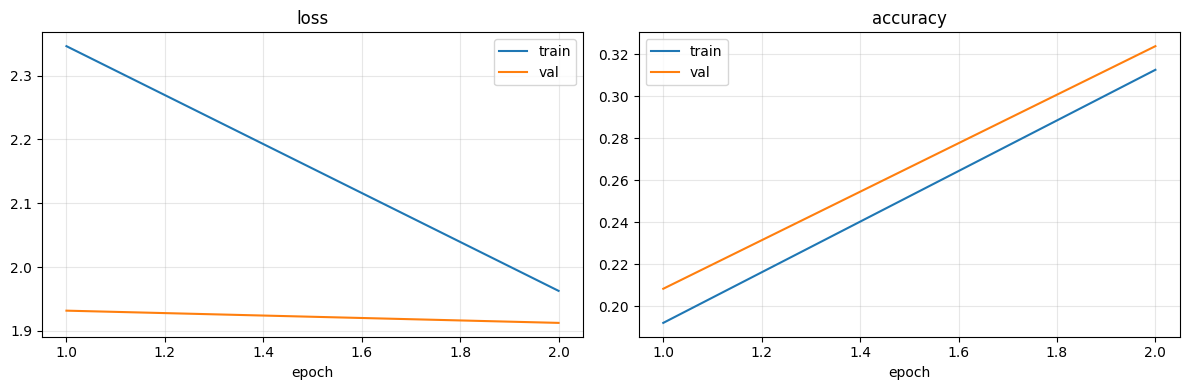

Test set -> BEST-validation weights
93/93 [==============================] - 11s 74ms/step
              precision    recall  f1-score   support

       akiec     0.1174    0.7174    0.2018        46
         bcc     0.0000    0.0000    0.0000        71
         bkl     0.0000    0.0000    0.0000       168
          df     0.0280    0.3000    0.0513        20
         mel     0.2237    0.4121    0.2900       165
          nv     0.8538    0.3710    0.5172       992
        vasc     0.0200    0.2632    0.0372        19

    accuracy                         0.3241      1481
   macro avg     0.1776    0.2948    0.1568      1481
weighted avg     0.6011    0.3241    0.3862      1481

accuracy: 0.3241 | balanced_accuracy: 0.2948 | precision_macro: 0.1776 | recall_macro: 0.2948 | f1_macro: 0.1568 | roc_auc_macro_ovr: 0.7341


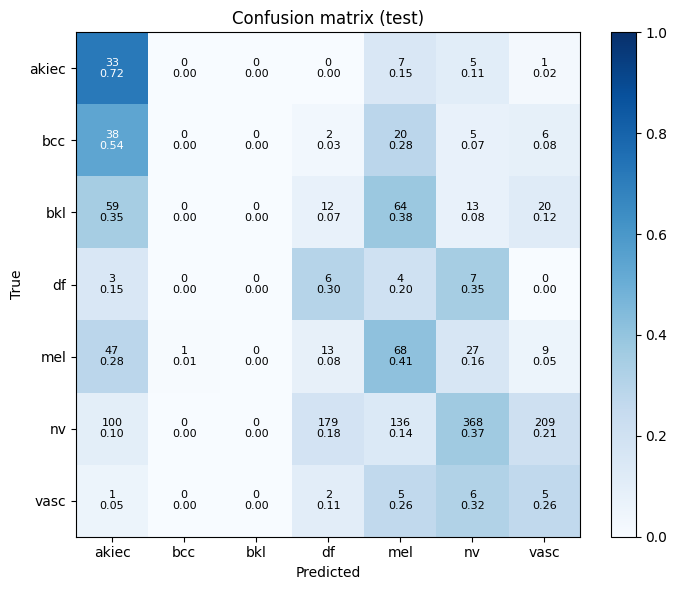


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.3522,0.3392,0.1725,0.7396
Validation,0.3238,0.2852,0.1598,0.6954
Test,0.3241,0.2948,0.1568,0.7341
Gap (train - val),0.0284,0.0540,0.0127,0.0442


Train vs validation balanced accuracy gap: 0.054 (small gap but low scores -> underfitting)


In [24]:
_saved = TARGET_PER_CLASS
TARGET_PER_CLASS = 32       # tiny epoch just to test the pipeline
run_experiment(warmup_epochs=1, finetune_epochs=1, run_name="smoke_test")
gc.collect()
TARGET_PER_CLASS = _saved

## 11. Comparison models (train these first, in this order)
Each model is trained **separately, from scratch**, with the same data split and settings.
Run one cell at a time and wait for it to finish. Results go to their own folder under `outputs_strict/`.

| Order | Model | Attention | Clinical data | Shows |
|---|---|:-:|:-:|---|
| 11.1 | Model 1: Clinical only | – | ✓ | what patient data alone can do (a few minutes) |
| 11.2 | Model 2: **Baseline** (DenseNet121, image only) | ✗ | ✗ | starting point |
| 11.3 | Model 3: + Attention (image only) | ✓ | ✗ | value of the attention block |
| 11.4 | Model 4: + Clinical (no attention) | ✗ | ✓ | value of clinical data |
| 11.5 | Model 5: SE + Clinical | SE | ✓ | standard channel attention |
| 11.6 | Model 6: CBAM + Clinical | CBAM | ✓ | standard channel + spatial attention |
| **12** | **Model 7: Proposed** | **✓** | **✓** | **final result** |

Models 4, 5, 6 and 7 use the same DenseNet121 + clinical MLP and differ only in the attention module
(none, SE, CBAM, proposed). Optional extras after section 12: seed repeats (13) and MobileNetV2 (13b).

If a run is interrupted, re-run the same cell with `resume=True` added.

### 11.1 Model 1: **Clinical only** (MLP on age, sex and body site; a few minutes)

Run: clinical_only -> outputs_strict_oversample_fixedlr\clinical_only
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Epoch 1/100
875/875 [==============================] - ETA: 0s - loss: 1.8200 - accuracy: 0.3135 - auc: 0.7151
Epoch 1: val_loss improved from inf to 1.70312, saving model to outputs_strict_oversample_fixedlr\clinical_only\best.ckpt
875/875 [==============================] - 21s 20ms/step - loss: 1.8200 - accuracy: 0.3135 - auc: 0.7151 - val_loss: 1.7031 - val_accuracy: 0.3068 - val_auc: 0.7564
Epoch 2/100
873/875 [============================>.] - ETA: 0s - loss: 1.6637 - accuracy: 0.3626 - auc: 0.7619
Epoch 2: val_loss improved from 1.70312 to 1.54816, saving model to outputs_strict_oversample_fixedlr\clinical_only\best.ckpt
875/875 [==============================] - 16s 18ms/step - loss: 1.6637 - accuracy: 0.3626 - auc: 0.7619 - val_loss: 1.5482 - val_accuracy: 0.4269 - val_auc: 0.8002
Epoch 3/100
874/875 [============================>.] - ETA: 0s - loss: 1.6

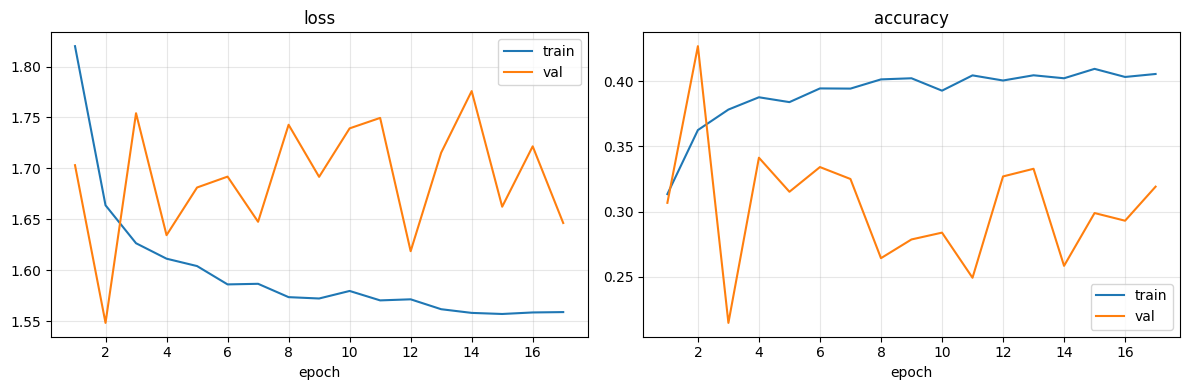

Test set -> BEST-validation weights
93/93 [==============================] - 1s 6ms/step
              precision    recall  f1-score   support

       akiec     0.1342    0.4348    0.2051        46
         bcc     0.1829    0.4507    0.2602        71
         bkl     0.4355    0.1607    0.2348       168
          df     0.0538    0.8500    0.1012        20
         mel     0.0581    0.0303    0.0398       165
          nv     0.8902    0.5232    0.6590       992
        vasc     0.0000    0.0000    0.0000        19

    accuracy                         0.4186      1481
   macro avg     0.2507    0.3500    0.2143      1481
weighted avg     0.6658    0.4186    0.4927      1481

accuracy: 0.4186 | balanced_accuracy: 0.3500 | precision_macro: 0.2507 | recall_macro: 0.3500 | f1_macro: 0.2143 | roc_auc_macro_ovr: 0.7473


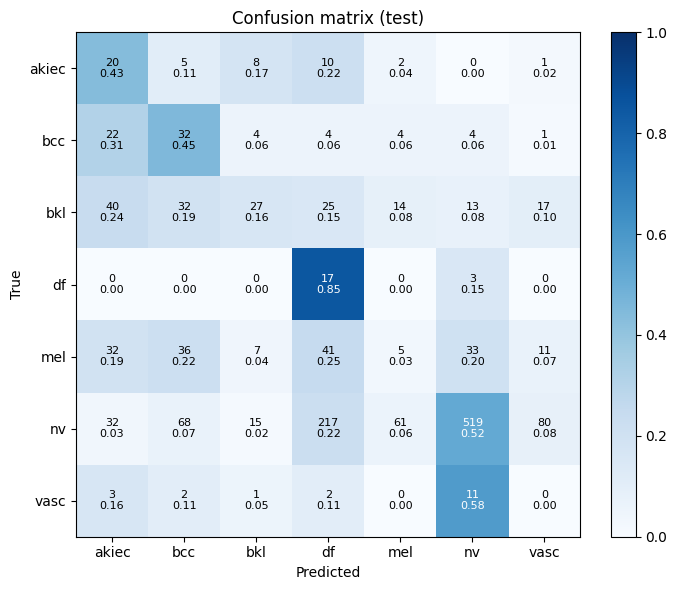


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.4380,0.4196,0.2520,0.8103
Validation,0.4269,0.3261,0.2226,0.7286
Test,0.4186,0.3500,0.2143,0.7473
Gap (train - val),0.0111,0.0935,0.0294,0.0817


Train vs validation balanced accuracy gap: 0.093 (small gap but low scores -> underfitting)


In [25]:
RUN_clin = run_experiment(model_type="clinical_only")[1]   # keeps only the results folder, frees memory

### 11.2 Model 2: **Baseline**: DenseNet121, image only (no attention, no clinical data)

Run: densenet121_noattn_image_only -> outputs_strict_oversample_fixedlr\densenet121_noattn_image_only
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

=== Phase 1: backbone frozen
Epoch 1/5
875/875 [==============================] - ETA: 0s - loss: 1.4696 - accuracy: 0.4728 - auc: 0.8342
Epoch 1: val_loss improved from inf to 1.28818, saving model to outputs_strict_oversample_fixedlr\densenet121_noattn_image_only\best.ckpt
875/875 [==============================] - 164s 142ms/step - loss: 1.4696 - accuracy: 0.4728 - auc: 0.8342 - val_loss: 1.2882 - val_accuracy: 0.5398 - val_auc: 0.8772
Epoch 2/5
875/875 [==============================] - ETA: 0s - loss: 1.2628 - accuracy: 0.5624 - auc: 0.8848
Epoch 2: val_loss improved from 1.28818 to 1.14334, saving model to outputs_strict_oversample_fixedlr\densenet121_noattn_image_only\best.ckpt
875/875 [==============================] - 110s 125ms/step - loss: 1.2628 - accuracy: 0.5624 - auc: 0.8848 - val_loss: 1.1433 - val_accuracy: 0.600

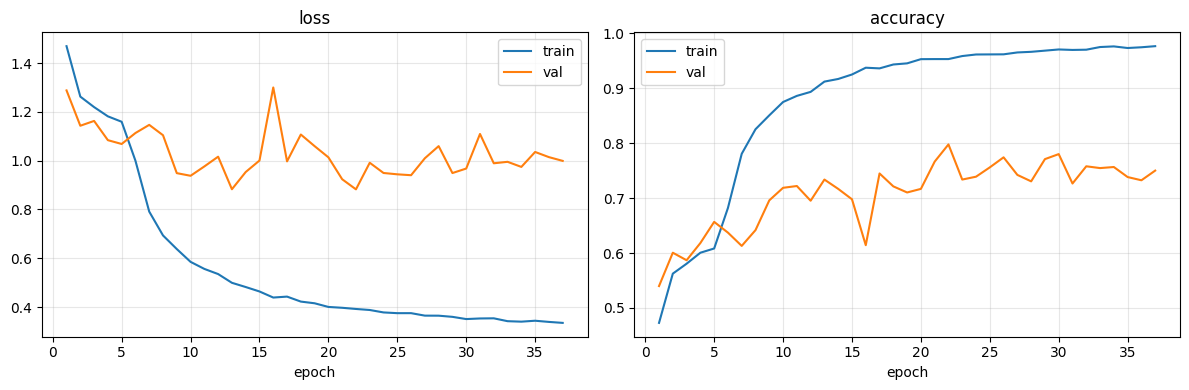

Test set -> BEST-validation weights
93/93 [==============================] - 11s 70ms/step
              precision    recall  f1-score   support

       akiec     0.4839    0.3261    0.3896        46
         bcc     0.7455    0.5775    0.6508        71
         bkl     0.5459    0.6726    0.6027       168
          df     0.5294    0.9000    0.6667        20
         mel     0.6765    0.4182    0.5169       165
          nv     0.9066    0.9395    0.9228       992
        vasc     0.5833    0.7368    0.6512        19

    accuracy                         0.8116      1481
   macro avg     0.6387    0.6530    0.6286      1481
weighted avg     0.8100    0.8116    0.8047      1481

accuracy: 0.8116 | balanced_accuracy: 0.6530 | precision_macro: 0.6387 | recall_macro: 0.6530 | f1_macro: 0.6286 | roc_auc_macro_ovr: 0.9421


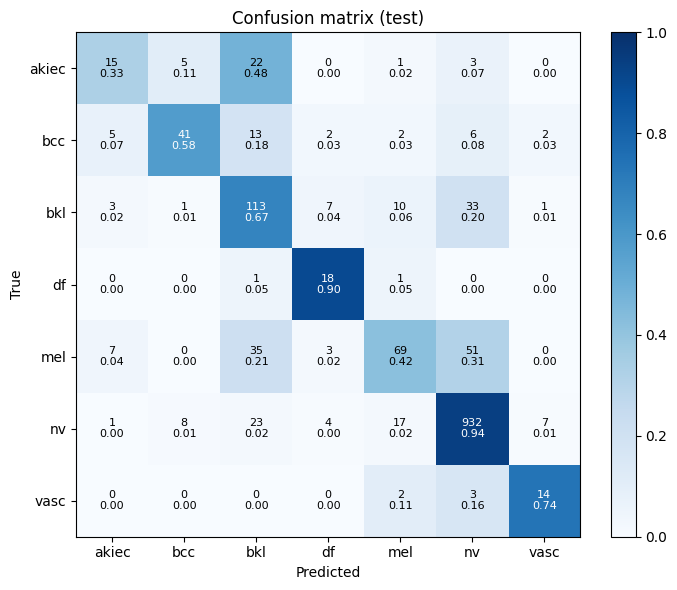


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.9383,0.9344,0.9232,0.9962
Validation,0.7977,0.6227,0.6189,0.9117
Test,0.8116,0.6530,0.6286,0.9421
Gap (train - val),0.1406,0.3117,0.3043,0.0845


Train vs validation balanced accuracy gap: 0.312 (large gap -> overfitting)


In [26]:
RUN_base = run_experiment(model_type="image_only", backbone="densenet121", attention="none")[1]   # keeps only the results folder, frees memory

### 11.3 Model 3: DenseNet121 **+ Attention Block** (image only, no clinical data)

Run: densenet121_attn_image_only -> outputs_strict_oversample_fixedlr\densenet121_attn_image_only
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

=== Phase 1: backbone frozen
Epoch 1/5
875/875 [==============================] - ETA: 0s - loss: 1.4656 - accuracy: 0.4691 - auc: 0.8263
Epoch 1: val_loss improved from inf to 1.23185, saving model to outputs_strict_oversample_fixedlr\densenet121_attn_image_only\best.ckpt
875/875 [==============================] - 298s 290ms/step - loss: 1.4656 - accuracy: 0.4691 - auc: 0.8263 - val_loss: 1.2318 - val_accuracy: 0.5822 - val_auc: 0.8936
Epoch 2/5
875/875 [==============================] - ETA: 0s - loss: 1.2425 - accuracy: 0.5704 - auc: 0.8899
Epoch 2: val_loss improved from 1.23185 to 1.15477, saving model to outputs_strict_oversample_fixedlr\densenet121_attn_image_only\best.ckpt
875/875 [==============================] - 214s 245ms/step - loss: 1.2425 - accuracy: 0.5704 - auc: 0.8899 - val_loss: 1.1548 - val_accuracy: 0.5796 - val_

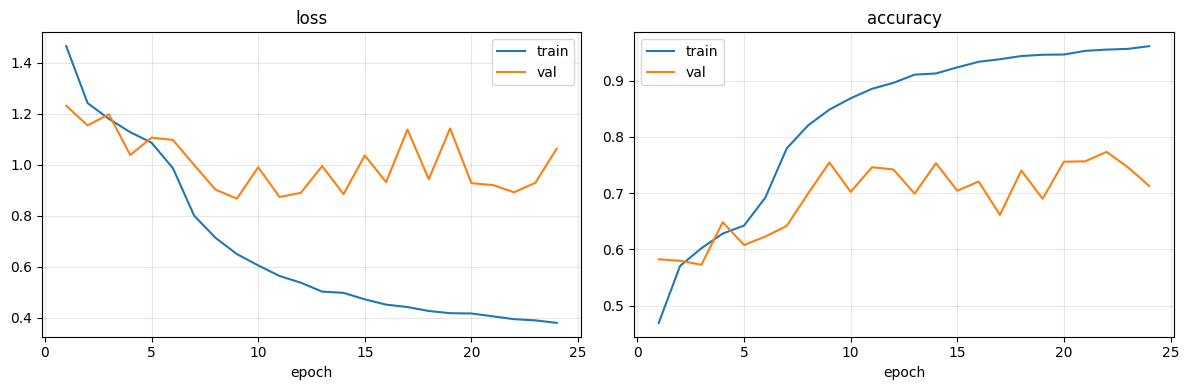

Test set -> BEST-validation weights
93/93 [==============================] - 12s 83ms/step
              precision    recall  f1-score   support

       akiec     0.3333    0.7391    0.4595        46
         bcc     0.5753    0.5915    0.5833        71
         bkl     0.5308    0.6667    0.5910       168
          df     0.3333    0.8500    0.4789        20
         mel     0.5882    0.4242    0.4930       165
          nv     0.9494    0.8508    0.8974       992
        vasc     0.4444    0.8421    0.5818        19

    accuracy                         0.7664      1481
   macro avg     0.5364    0.7092    0.5836      1481
weighted avg     0.8098    0.7664    0.7792      1481

accuracy: 0.7664 | balanced_accuracy: 0.7092 | precision_macro: 0.5364 | recall_macro: 0.7092 | f1_macro: 0.5836 | roc_auc_macro_ovr: 0.9465


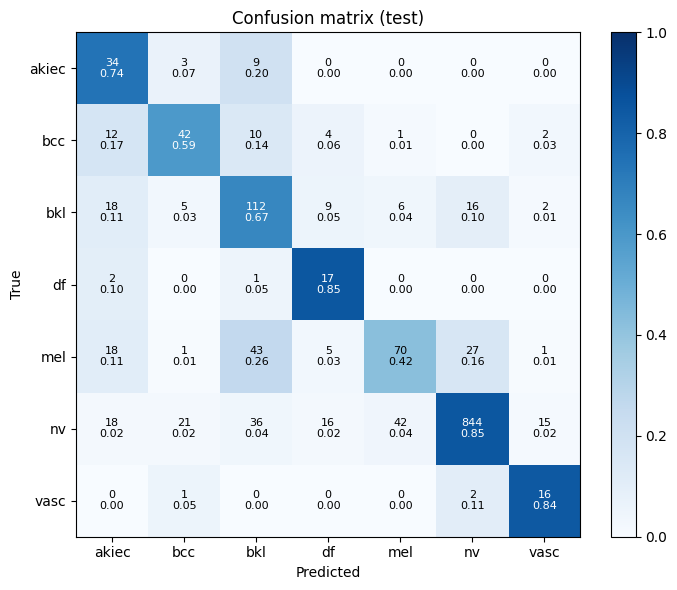


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.8460,0.8811,0.7705,0.9811
Validation,0.7546,0.6788,0.5835,0.9340
Test,0.7664,0.7092,0.5836,0.9465
Gap (train - val),0.0914,0.2023,0.1870,0.0471


Train vs validation balanced accuracy gap: 0.202 (large gap -> overfitting)


In [28]:
RUN_img = run_experiment(model_type="image_only", backbone="densenet121", attention="proposed")[1]   # keeps only the results folder, frees memory

### 11.4 Model 4: DenseNet121 **+ Clinical MLP** (no attention block)

Run: densenet121_noattn_fusion -> outputs_strict_oversample_fixedlr\densenet121_noattn_fusion
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

=== Phase 1: backbone frozen
Epoch 1/5
875/875 [==============================] - ETA: 0s - loss: 1.3425 - accuracy: 0.5389 - auc: 0.8687
Epoch 1: val_loss improved from inf to 1.23126, saving model to outputs_strict_oversample_fixedlr\densenet121_noattn_fusion\best.ckpt
875/875 [==============================] - 313s 307ms/step - loss: 1.3425 - accuracy: 0.5389 - auc: 0.8687 - val_loss: 1.2313 - val_accuracy: 0.5672 - val_auc: 0.8930
Epoch 2/5
875/875 [==============================] - ETA: 0s - loss: 1.1202 - accuracy: 0.6267 - auc: 0.9169
Epoch 2: val_loss improved from 1.23126 to 1.04729, saving model to outputs_strict_oversample_fixedlr\densenet121_noattn_fusion\best.ckpt
875/875 [==============================] - 247s 282ms/step - loss: 1.1202 - accuracy: 0.6267 - auc: 0.9169 - val_loss: 1.0473 - val_accuracy: 0.6560 - val_auc: 0.9

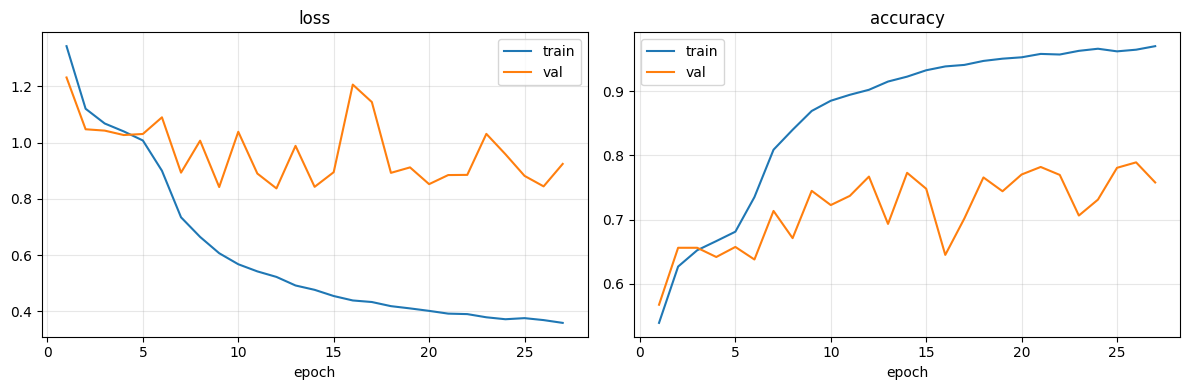

Test set -> BEST-validation weights
93/93 [==============================] - 12s 81ms/step
              precision    recall  f1-score   support

       akiec     0.9231    0.2609    0.4068        46
         bcc     0.7619    0.6761    0.7164        71
         bkl     0.5944    0.6369    0.6149       168
          df     0.6842    0.6500    0.6667        20
         mel     0.4796    0.7818    0.5945       165
          nv     0.9566    0.8881    0.9211       992
        vasc     0.8750    0.7368    0.8000        19

    accuracy                         0.8130      1481
   macro avg     0.7535    0.6615    0.6743      1481
weighted avg     0.8472    0.8130    0.8192      1481

accuracy: 0.8130 | balanced_accuracy: 0.6615 | precision_macro: 0.7535 | recall_macro: 0.6615 | f1_macro: 0.6743 | roc_auc_macro_ovr: 0.9512


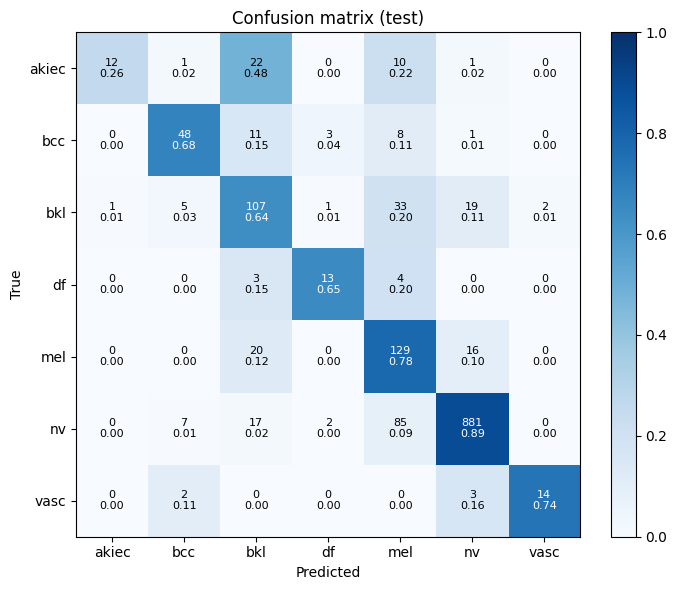


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.8886,0.8920,0.8750,0.9927
Validation,0.7670,0.6075,0.6159,0.9327
Test,0.8130,0.6615,0.6743,0.9512
Gap (train - val),0.1216,0.2845,0.2591,0.0600


Train vs validation balanced accuracy gap: 0.284 (large gap -> overfitting)


In [29]:
RUN_noattn = run_experiment(model_type="fusion", backbone="densenet121", attention="none")[1]   # keeps only the results folder, frees memory

### 11.5 Model 5: DenseNet121 + **SE attention** + Clinical MLP

Run: densenet121_se_fusion -> outputs_strict_oversample_fixedlr\densenet121_se_fusion
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

=== Phase 1: backbone frozen
Epoch 1/5
875/875 [==============================] - ETA: 0s - loss: 1.3002 - accuracy: 0.5573 - auc: 0.8805
Epoch 1: val_loss improved from inf to 1.10808, saving model to outputs_strict_oversample_fixedlr\densenet121_se_fusion\best.ckpt
875/875 [==============================] - 338s 333ms/step - loss: 1.3002 - accuracy: 0.5573 - auc: 0.8805 - val_loss: 1.1081 - val_accuracy: 0.6227 - val_auc: 0.9191
Epoch 2/5
875/875 [==============================] - ETA: 0s - loss: 1.0083 - accuracy: 0.6791 - auc: 0.9380
Epoch 2: val_loss improved from 1.10808 to 0.97956, saving model to outputs_strict_oversample_fixedlr\densenet121_se_fusion\best.ckpt
875/875 [==============================] - 268s 307ms/step - loss: 1.0083 - accuracy: 0.6791 - auc: 0.9380 - val_loss: 0.9796 - val_accuracy: 0.6932 - val_auc: 0.9446
Epoch 3/5
87

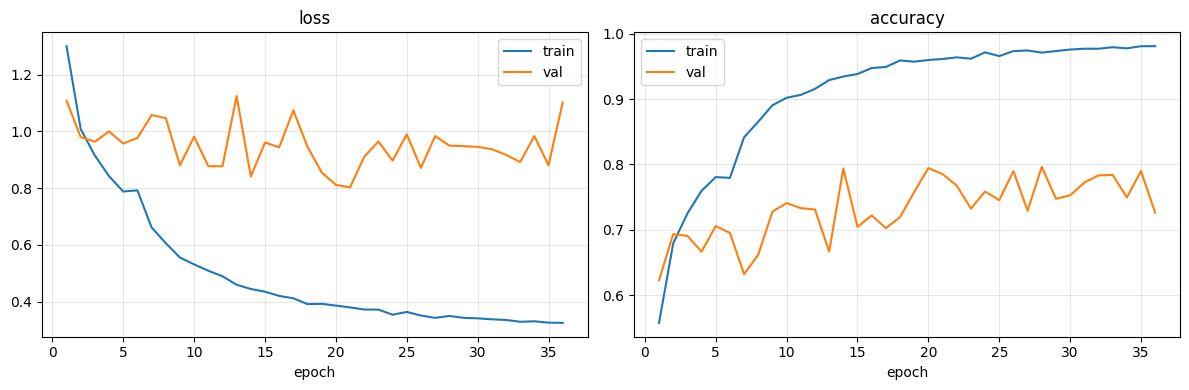

Test set -> BEST-validation weights
93/93 [==============================] - 12s 84ms/step
              precision    recall  f1-score   support

       akiec     0.4222    0.4130    0.4176        46
         bcc     0.7188    0.6479    0.6815        71
         bkl     0.5292    0.7560    0.6225       168
          df     0.8667    0.6500    0.7429        20
         mel     0.5556    0.5152    0.5346       165
          nv     0.9411    0.9022    0.9213       992
        vasc     0.9231    0.6316    0.7500        19

    accuracy                         0.8082      1481
   macro avg     0.7081    0.6451    0.6672      1481
weighted avg     0.8234    0.8082    0.8125      1481

accuracy: 0.8082 | balanced_accuracy: 0.6451 | precision_macro: 0.7081 | recall_macro: 0.6451 | f1_macro: 0.6672 | roc_auc_macro_ovr: 0.9452


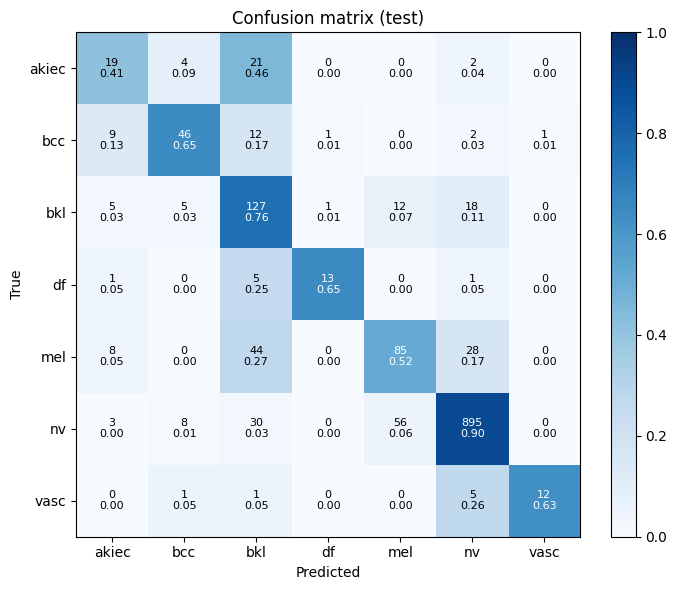


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.9477,0.9717,0.9522,0.9975
Validation,0.7852,0.6278,0.6358,0.9447
Test,0.8082,0.6451,0.6672,0.9452
Gap (train - val),0.1625,0.3439,0.3164,0.0528


Train vs validation balanced accuracy gap: 0.344 (large gap -> overfitting)


In [30]:
RUN_se = run_experiment(model_type="fusion", backbone="densenet121", attention="se")[1]   # keeps only the results folder, frees memory

### 11.6 Model 6: DenseNet121 + **CBAM attention** + Clinical MLP

Run: densenet121_cbam_fusion -> outputs_strict_oversample_fixedlr\densenet121_cbam_fusion
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

=== Phase 1: backbone frozen
Epoch 1/5
875/875 [==============================] - ETA: 0s - loss: 1.3067 - accuracy: 0.5563 - auc: 0.8791
Epoch 1: val_loss improved from inf to 1.17519, saving model to outputs_strict_oversample_fixedlr\densenet121_cbam_fusion\best.ckpt
875/875 [==============================] - 395s 396ms/step - loss: 1.3067 - accuracy: 0.5563 - auc: 0.8791 - val_loss: 1.1752 - val_accuracy: 0.6097 - val_auc: 0.9042
Epoch 2/5
875/875 [==============================] - ETA: 0s - loss: 1.0028 - accuracy: 0.6801 - auc: 0.9389
Epoch 2: val_loss improved from 1.17519 to 1.04827, saving model to outputs_strict_oversample_fixedlr\densenet121_cbam_fusion\best.ckpt
875/875 [==============================] - 323s 369ms/step - loss: 1.0028 - accuracy: 0.6801 - auc: 0.9389 - val_loss: 1.0483 - val_accuracy: 0.6625 - val_auc: 0.9343
Epoc

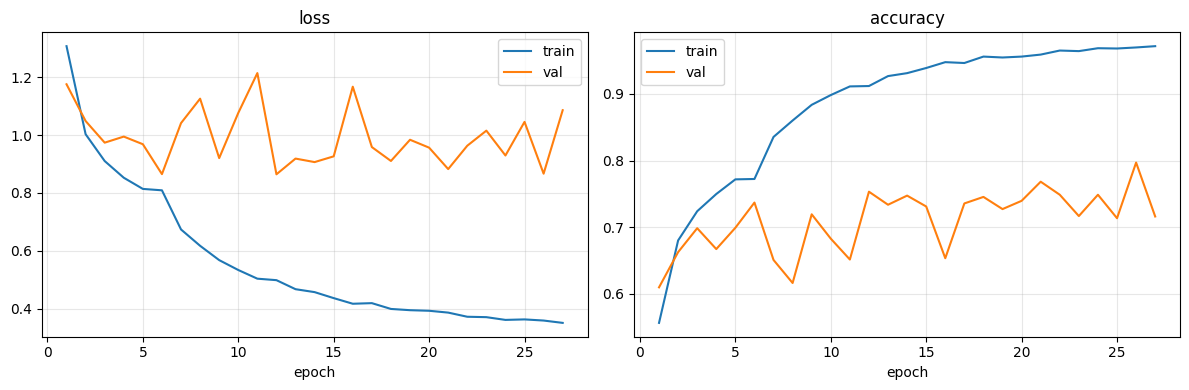

Test set -> BEST-validation weights
93/93 [==============================] - 13s 90ms/step
              precision    recall  f1-score   support

       akiec     0.5385    0.3043    0.3889        46
         bcc     0.6508    0.5775    0.6119        71
         bkl     0.4671    0.8036    0.5908       168
          df     0.6471    0.5500    0.5946        20
         mel     0.5577    0.5273    0.5421       165
          nv     0.9531    0.8810    0.9157       992
        vasc     1.0000    0.6842    0.8125        19

    accuracy                         0.7934      1481
   macro avg     0.6877    0.6183    0.6366      1481
weighted avg     0.8230    0.7934    0.8006      1481

accuracy: 0.7934 | balanced_accuracy: 0.6183 | precision_macro: 0.6877 | recall_macro: 0.6183 | f1_macro: 0.6366 | roc_auc_macro_ovr: 0.9423


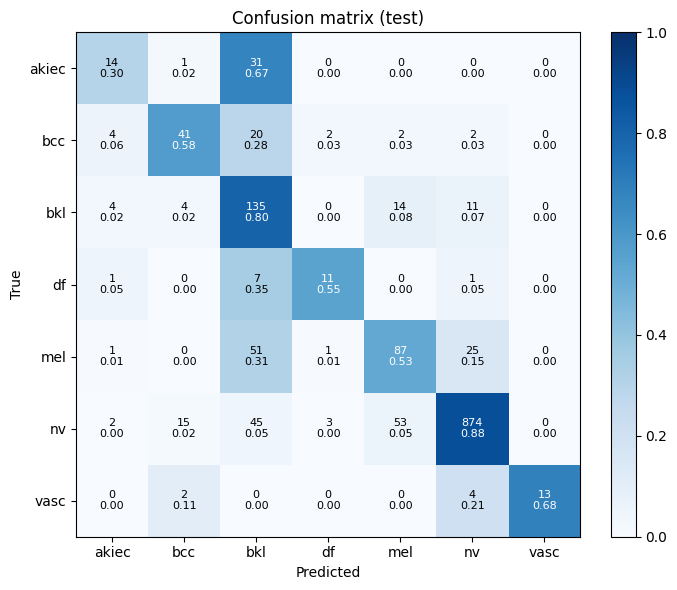


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.9037,0.9192,0.8967,0.9937
Validation,0.7533,0.5792,0.5730,0.9253
Test,0.7934,0.6183,0.6366,0.9423
Gap (train - val),0.1504,0.3400,0.3237,0.0684


Train vs validation balanced accuracy gap: 0.340 (large gap -> overfitting)


In [31]:
RUN_cbam = run_experiment(model_type="fusion", backbone="densenet121", attention="cbam")[1]   # keeps only the results folder, frees memory

## 12. Model 7: **Proposed model**: DenseNet121 + Attention Block + Clinical MLP (final result)
This is the only model kept in memory; sections 14, 15 and 20 use it (`model`, `RUN`).
If you restarted the kernel after training, reload it instead of retraining (section 22):
`RUN = os.path.join(OUTPUT_DIR, "densenet121_attn_fusion"); model = load_trained(RUN)`

Run: densenet121_attn_fusion -> outputs_strict_oversample_fixedlr\densenet121_attn_fusion
Training on GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

=== Phase 1: backbone frozen
Epoch 1/5
875/875 [==============================] - ETA: 0s - loss: 1.3643 - accuracy: 0.5272 - auc: 0.8638
Epoch 1: val_loss improved from inf to 1.20461, saving model to outputs_strict_oversample_fixedlr\densenet121_attn_fusion\best.ckpt
875/875 [==============================] - 437s 443ms/step - loss: 1.3643 - accuracy: 0.5272 - auc: 0.8638 - val_loss: 1.2046 - val_accuracy: 0.5822 - val_auc: 0.8988
Epoch 2/5
875/875 [==============================] - ETA: 0s - loss: 1.0924 - accuracy: 0.6386 - auc: 0.9223
Epoch 2: val_loss improved from 1.20461 to 1.00562, saving model to outputs_strict_oversample_fixedlr\densenet121_attn_fusion\best.ckpt
875/875 [==============================] - 365s 417ms/step - loss: 1.0924 - accuracy: 0.6386 - auc: 0.9223 - val_loss: 1.0056 - val_accuracy: 0.6789 - val_auc: 0.9380
Epoc

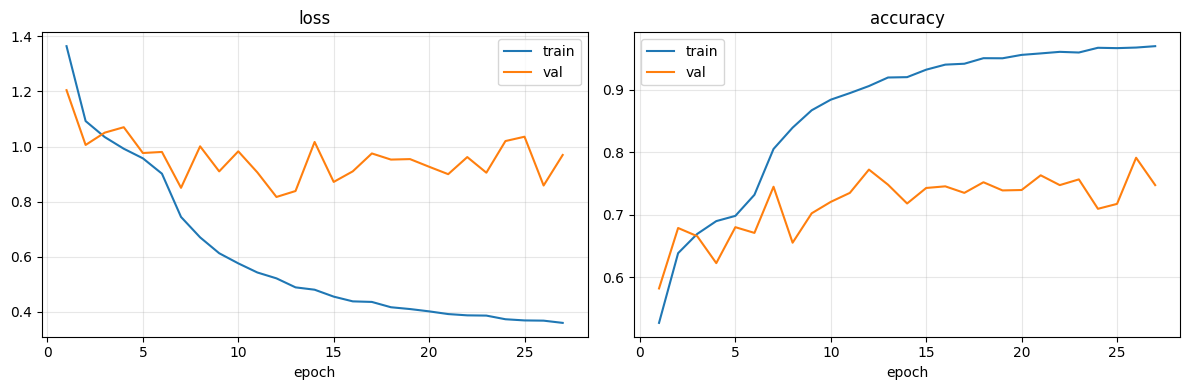

Test set -> BEST-validation weights
93/93 [==============================] - 13s 94ms/step
              precision    recall  f1-score   support

       akiec     0.5405    0.4348    0.4819        46
         bcc     0.6825    0.6056    0.6418        71
         bkl     0.6379    0.6607    0.6491       168
          df     0.7273    0.8000    0.7619        20
         mel     0.4425    0.7697    0.5619       165
          nv     0.9648    0.8569    0.9076       992
        vasc     0.7059    0.6316    0.6667        19

    accuracy                         0.7961      1481
   macro avg     0.6716    0.6799    0.6673      1481
weighted avg     0.8363    0.7961    0.8088      1481

accuracy: 0.7961 | balanced_accuracy: 0.6799 | precision_macro: 0.6716 | recall_macro: 0.6799 | f1_macro: 0.6673 | roc_auc_macro_ovr: 0.9565


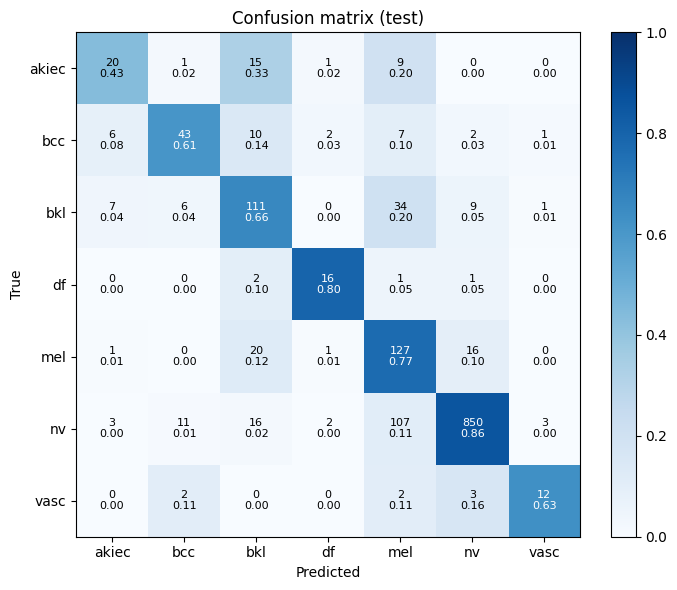


Same weights on each split (training images without augmentation):


,Accuracy,Balanced acc,Macro F1,Macro AUC
Train,0.8922,0.9318,0.8966,0.9932
Validation,0.7722,0.6438,0.6470,0.9218
Test,0.7961,0.6799,0.6673,0.9565
Gap (train - val),0.1200,0.2880,0.2496,0.0714


Train vs validation balanced accuracy gap: 0.288 (large gap -> overfitting)


In [32]:
model, RUN = run_experiment(model_type="fusion", backbone="densenet121", attention="proposed")
# interrupted?  ->  model, RUN = run_experiment(attention="proposed", resume=True)

## 13. Optional: repeat key models with 2 more seeds (mean ± std)
The runs above use seed 42. Repeating with seeds 1 and 2 shows the differences are not luck.
The **data split stays the same**; only weight initialisation, shuffling and augmentation change.
Each run takes as long as the original. Most important: Baseline, CBAM, Proposed (in this order).

In [ ]:
EXTRA_SEEDS = [1, 2]
for sd in EXTRA_SEEDS:
    run_experiment(model_type="image_only", backbone="densenet121", attention="none", seed=sd)      # Baseline
gc.collect();

In [ ]:
for sd in EXTRA_SEEDS:
    run_experiment(model_type="fusion", backbone="densenet121", attention="cbam", seed=sd)          # CBAM
gc.collect();

In [ ]:
for sd in EXTRA_SEEDS:
    run_experiment(model_type="fusion", backbone="densenet121", attention="proposed", seed=sd)      # Proposed
gc.collect();

**Optional extra seeds** (run if time allows; remove the `#` to run a line):

In [ ]:
# for sd in EXTRA_SEEDS: run_experiment(model_type="clinical_only", seed=sd)                                             # Clinical only
# for sd in EXTRA_SEEDS: run_experiment(model_type="image_only", backbone="densenet121", attention="proposed", seed=sd)  # + Attention
# for sd in EXTRA_SEEDS: run_experiment(model_type="fusion", backbone="densenet121", attention="none", seed=sd)          # + Clinical
# for sd in EXTRA_SEEDS: run_experiment(model_type="fusion", backbone="densenet121", attention="se", seed=sd)            # SE

## 13b. Optional: MobileNetV2 backbone + Attention Block + Clinical MLP
A lighter backbone, to compare with DenseNet121. Train only if time is left.

In [ ]:
RUN_mobile = run_experiment(model_type="fusion", backbone="mobilenetv2", attention="proposed")[1]   # keeps only the results folder, frees memory

## 14. Attention maps on test images (proposed model)

In [ ]:
def show_attention(model, n_per_class=2):
    viz = keras.Model(model.inputs, [model.get_layer("attention_block").output[1], model.output])
    sample = pd.concat([g.sample(min(len(g), n_per_class), random_state=1)
                        for _, g in test_df.groupby("dx")]).reset_index(drop=True)
    imgs = np.stack([load_image(lookup[i]).numpy() for i in sample["image_id"]])
    maps, probs = viz.predict({"image": imgs, "clinical": transform_clinical(sample, encoder)}, verbose=0)
    y = labels_of(sample)
    n = len(sample)
    fig, axes = plt.subplots(n // 2 + n % 2, 4, figsize=(12, 3 * (n // 2 + n % 2)))
    axes = np.array(axes).reshape(-1, 4)
    for ax in axes.ravel():
        ax.axis("off")
    for i in range(n):
        r, c = divmod(i, 2)
        m = tf.image.resize(maps[i].astype("float32"), (IMG_SIZE, IMG_SIZE)).numpy()[..., 0]
        m = (m - m.min()) / (m.max() - m.min() + 1e-8)
        pred = int(probs[i].argmax())
        axes[r, 2 * c].imshow(imgs[i].astype("uint8"))
        axes[r, 2 * c].set_title(f"true: {CLASS_NAMES[y[i]]}", fontsize=9)
        axes[r, 2 * c + 1].imshow(imgs[i].astype("uint8"))
        axes[r, 2 * c + 1].imshow(m, cmap="jet", alpha=0.45)
        axes[r, 2 * c + 1].set_title(f"pred: {CLASS_NAMES[pred]} ({probs[i, pred]:.2f})"
                                     f"{' OK' if pred == y[i] else ' X'}", fontsize=9)
    fig.suptitle("Attention Block maps (red = high attention)"); fig.tight_layout()
    fig.savefig(os.path.join(RUN, "attention_maps.png"), dpi=130); plt.show()


show_attention(model)

## 15. Predict a single image + clinical data

In [ ]:
def predict_one(model, image_path, age=None, sex="unknown", localization="unknown", dx_type="unknown"):
    row = pd.DataFrame([{"age": np.nan if age is None else age, "sex": sex,
                         "localization": localization, "dx_type": dx_type}])
    img = load_image(image_path).numpy()[None]
    probs = model.predict({"image": img, "clinical": transform_clinical(row, encoder)}, verbose=0)[0]
    for i in np.argsort(probs)[::-1]:
        print(f"  {CLASS_NAMES[i]:6s} {probs[i]:.4f}")


predict_one(model, lookup[test_df["image_id"].iloc[0]], age=test_df["age"].iloc[0],
            sex=test_df["sex"].iloc[0], localization=test_df["localization"].iloc[0])
print("true label:", test_df["dx"].iloc[0])

# Results for the paper
Sections 16–21 only **read saved results** (no training). Run them any time; models that are not
trained yet are skipped. Tables are also saved as CSV in `outputs_strict/` for your report.

## 16. Results tables: ablation study and attention comparison (seed 42)

In [ ]:
# (run folder, name, attention, clinical)
ABLATION = [("clinical_only",                 "1. Clinical only",          "–", "✓"),
            ("densenet121_noattn_image_only", "2. Baseline (DenseNet121)", "✗", "✗"),
            ("densenet121_attn_image_only",   "3. + Attention",            "✓", "✗"),
            ("densenet121_noattn_fusion",     "4. + Clinical",             "✗", "✓"),
            ("densenet121_attn_fusion",       "7. Proposed",               "✓", "✓")]
ATTN_CMP = [("densenet121_noattn_fusion", "4. No attention"),
            ("densenet121_se_fusion",     "5. SE (channel)"),
            ("densenet121_cbam_fusion",   "6. CBAM (channel + spatial)"),
            ("densenet121_attn_fusion",   "7. Proposed attention block")]
EXTRA = [("mobilenetv2_attn_fusion", "8. MobileNetV2 + Att + Clin (optional)")]
METRICS = {"accuracy": "Accuracy", "balanced_accuracy": "Balanced Acc", "f1_macro": "Macro F1",
           "roc_auc_macro_ovr": "Macro AUC"}


def metrics_of(run):
    f = os.path.join(OUTPUT_DIR, run, "test_metrics.json")
    return json.load(open(f)) if os.path.exists(f) else None


def show_df(df, highlight=None):
    """Display a table, highlighting the best value per column when pandas styling is available."""
    try:
        sty = df.style.format(precision=4)
        if highlight:
            sty = sty.highlight_max(subset=highlight, color="#c6efce")
        display(sty)
    except (AttributeError, ImportError):          # jinja2 missing -> plain table
        display(df.round(4))


def show_table(rows, title, csv_name):
    if not rows:
        print(f"{title}: no trained models yet"); return None
    t = pd.DataFrame(rows).set_index("Model")
    t.to_csv(os.path.join(OUTPUT_DIR, csv_name))
    print(title)
    show_df(t, list(METRICS.values()))
    return t


rows = []
for run, name, att, clin in ABLATION:
    m = metrics_of(run)
    if m:
        rows.append({"Model": name, "Attention": att, "Clinical": clin,
                     **{v: m[k] for k, v in METRICS.items()}})
show_table(rows, "Table A: Ablation study", "table_ablation.csv")

rows = []
for run, name in ATTN_CMP + EXTRA:
    m = metrics_of(run)
    if m:
        rows.append({"Model": name, **{v: m[k] for k, v in METRICS.items()}})
show_table(rows, "Table B: Attention module comparison (DenseNet121 + Clinical MLP)", "table_attention.csv");

## 17. Mean ± std over seeds (after section 13)

In [ ]:
SEED_MODELS = [("clinical_only",                 "1. Clinical only"),
               ("densenet121_noattn_image_only", "2. Baseline"),
               ("densenet121_attn_image_only",   "3. + Attention"),
               ("densenet121_noattn_fusion",     "4. + Clinical"),
               ("densenet121_se_fusion",         "5. SE"),
               ("densenet121_cbam_fusion",       "6. CBAM"),
               ("densenet121_attn_fusion",       "7. Proposed")]
rows = []
for run, name in SEED_MODELS:
    runs = [run] + [os.path.basename(d) for d in sorted(glob.glob(os.path.join(OUTPUT_DIR, run + "_s*")))]
    ms = [m for m in (metrics_of(r) for r in runs) if m]
    if not ms:
        continue
    row = {"Model": name, "Runs": len(ms)}
    for k, v in METRICS.items():
        vals = np.array([m[k] for m in ms])
        row[v] = f"{vals.mean():.4f} ± {vals.std(ddof=1) if len(vals) > 1 else 0:.4f}"
    rows.append(row)
if rows:
    seed_table = pd.DataFrame(rows).set_index("Model")
    seed_table.to_csv(os.path.join(OUTPUT_DIR, "table_seeds_mean_std.csv"))
    display(seed_table)
else:
    print("no runs yet")

## 18. ROC curves per class (proposed model)

In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc


def plot_roc(run, title):
    f = os.path.join(OUTPUT_DIR, run, "test_predictions.csv")
    if not os.path.exists(f):
        print("not trained yet:", run); return
    df = pd.read_csv(f)
    y = df["true"].map({c: i for i, c in enumerate(CLASS_NAMES)}).to_numpy()
    probs = df[[f"p_{c}" for c in CLASS_NAMES]].to_numpy()
    fig, ax = plt.subplots(figsize=(7, 6))
    for k, c in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve((y == k).astype(int), probs[:, k])
        ax.plot(fpr, tpr, lw=1.6, label=f"{c} (AUC = {sk_auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate (sensitivity)")
    ax.set_title(title); ax.legend(loc="lower right"); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(OUTPUT_DIR, run, "roc_curves.png"), dpi=150); plt.show()


plot_roc("densenet121_attn_fusion", "ROC curves: proposed model (test set)")

## 19. Model size and inference speed
Parameters, size and inference time per image for each architecture
(measured on this machine with random inputs, so no trained weights are needed).

In [ ]:
EFF = [("2. Baseline (DenseNet121)", dict(model_type="image_only", attention="none")),
       ("4. + Clinical (no attention)", dict(model_type="fusion", attention="none")),
       ("5. SE", dict(model_type="fusion", attention="se")),
       ("6. CBAM", dict(model_type="fusion", attention="cbam")),
       ("7. Proposed", dict(model_type="fusion", attention="proposed")),
       ("8. MobileNetV2 + Att + Clin", dict(model_type="fusion", attention="proposed", backbone="mobilenetv2"))]
ATT_LAYER = {"proposed": "attention_block", "cbam": "cbam_block", "se": "se_block"}
rows = []
for name, kw in EFF:
    keras.backend.clear_session()
    m = build_model(weights=None, **kw)
    att = kw.get("attention", "none")
    att_params = m.get_layer(ATT_LAYER[att]).count_params() if att in ATT_LAYER else 0
    x = {"image": np.random.rand(16, IMG_SIZE, IMG_SIZE, 3).astype("float32") * 255,
         "clinical": np.random.rand(16, CLINICAL_DIM).astype("float32")}
    f = tf.function(lambda inp: m(inp, training=False))
    f(x)                                                     # warm-up
    t0 = time.time()
    for _ in range(5):
        _ = f(x)
    ms_per_img = (time.time() - t0) / (5 * 16) * 1000
    rows.append({"Model": name, "Total params": f"{m.count_params():,}",
                 "Attention params": f"{att_params:,}",
                 "Size (MB, fp32)": round(m.count_params() * 4 / 1e6, 2),
                 "ms / image": round(ms_per_img, 2)})
    del m, f; gc.collect()
eff_table = pd.DataFrame(rows).set_index("Model")
eff_table.to_csv(os.path.join(OUTPUT_DIR, "table_efficiency.csv"))
print("Device:", "GPU" if GPUS else "CPU")
display(eff_table)
keras.backend.clear_session()

## 20. Attention map vs Grad-CAM (proposed model)
Grad-CAM shows which regions drove the prediction; the attention map shows where the attention
block focused. If both highlight the lesion, it supports that the block attends to the right area.

In [ ]:
def grad_cam(model, inputs, class_idx):
    att = model.get_layer("attention_block")
    gm = keras.Model(model.inputs, [att.output[0], model.output])
    with tf.GradientTape() as tape:
        feats, preds = gm(inputs, training=False)
        feats = tf.cast(feats, tf.float32)
        tape.watch(feats)
        score = tf.reduce_sum(tf.cast(preds, tf.float32) * tf.one_hot(class_idx, NUM_CLASSES), axis=1)
    grads = tape.gradient(score, feats)
    w = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(w * feats, axis=-1))
    return cam.numpy()


def show_attention_vs_gradcam(model, n_per_class=1):
    sample = pd.concat([g.sample(min(len(g), n_per_class), random_state=3)
                        for _, g in test_df.groupby("dx")]).reset_index(drop=True)
    imgs = np.stack([load_image(lookup[i]).numpy() for i in sample["image_id"]])
    inputs = {"image": tf.constant(imgs), "clinical": tf.constant(transform_clinical(sample, encoder))}
    viz = keras.Model(model.inputs, [model.get_layer("attention_block").output[1], model.output])
    maps, probs = viz.predict({k: v.numpy() for k, v in inputs.items()}, verbose=0)
    preds = probs.argmax(1)
    cams = grad_cam(model, inputs, tf.constant(preds))
    y = labels_of(sample)
    norm = lambda a: (a - a.min()) / (a.max() - a.min() + 1e-8)
    up = lambda a: tf.image.resize(a[..., None].astype("float32"), (IMG_SIZE, IMG_SIZE)).numpy()[..., 0]
    fig, axes = plt.subplots(len(sample), 3, figsize=(9, 3 * len(sample)))
    axes = np.array(axes).reshape(-1, 3)
    for i in range(len(sample)):
        img = imgs[i].astype("uint8")
        axes[i, 0].imshow(img); axes[i, 0].set_title(f"true: {CLASS_NAMES[y[i]]}", fontsize=9)
        axes[i, 1].imshow(img); axes[i, 1].imshow(norm(up(maps[i][..., 0])), cmap="jet", alpha=0.45)
        axes[i, 1].set_title("Attention map", fontsize=9)
        axes[i, 2].imshow(img); axes[i, 2].imshow(norm(up(cams[i])), cmap="jet", alpha=0.45)
        axes[i, 2].set_title(f"Grad-CAM (pred: {CLASS_NAMES[preds[i]]})", fontsize=9)
        for ax in axes[i]:
            ax.axis("off")
    fig.tight_layout(); fig.savefig(os.path.join(RUN, "attention_vs_gradcam.png"), dpi=130); plt.show()


show_attention_vs_gradcam(model)

## 21. Melanoma-focused results and McNemar's test
**Melanoma (mel)** is the most dangerous class, so papers report its sensitivity (recall) and
specificity separately. **McNemar's test** checks whether the proposed model's errors differ
significantly from each other model's on the same test images (p < 0.05 = significant).

In [ ]:
from scipy.stats import chi2, binom

ALL_MODELS = ([(r, n) for r, n, *_ in ABLATION[:4]] + ATTN_CMP[1:3]
              + [(r, n) for r, n, *_ in ABLATION[4:]] + EXTRA)          # models 1-8 in order
ALL_MODELS = list(dict.fromkeys(ALL_MODELS))          # remove duplicates, keep order
MEL = CLASS_NAMES.index("mel")


def load_preds(run):
    f = os.path.join(OUTPUT_DIR, run, "test_predictions.csv")
    if not os.path.exists(f):
        return None
    df = pd.read_csv(f)
    y = df["true"].map({c: i for i, c in enumerate(CLASS_NAMES)}).to_numpy()
    p = df["pred"].map({c: i for i, c in enumerate(CLASS_NAMES)}).to_numpy()
    probs = df[[f"p_{c}" for c in CLASS_NAMES]].to_numpy()
    return df["image_id"].to_numpy(), y, p, probs


rows = []
for run, name in ALL_MODELS:
    d = load_preds(run)
    if d is None:
        continue
    _, y, p, probs = d
    tp = np.sum((y == MEL) & (p == MEL)); fn = np.sum((y == MEL) & (p != MEL))
    tn = np.sum((y != MEL) & (p != MEL)); fp = np.sum((y != MEL) & (p == MEL))
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    rows.append({"Model": name, "Mel sensitivity (recall)": rec, "Mel specificity": tn / max(tn + fp, 1),
                 "Mel precision": prec, "Mel F1": 2 * prec * rec / max(prec + rec, 1e-8),
                 "Mel AUC": roc_auc_score((y == MEL).astype(int), probs[:, MEL])})
if rows:
    mel_table = pd.DataFrame(rows).set_index("Model")
    mel_table.to_csv(os.path.join(OUTPUT_DIR, "table_melanoma.csv"))
    print("Melanoma (mel vs rest) on the test set")
    show_df(mel_table, list(mel_table.columns))


def mcnemar(y, pa, pb):
    """b = A right & B wrong, c = A wrong & B right. Exact binomial test if b+c < 25."""
    a_ok, b_ok = pa == y, pb == y
    b, c = int(np.sum(a_ok & ~b_ok)), int(np.sum(~a_ok & b_ok))
    if b + c == 0:
        return b, c, 1.0
    if b + c < 25:
        return b, c, float(min(1.0, 2 * binom.cdf(min(b, c), b + c, 0.5)))
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    return b, c, float(chi2.sf(stat, 1))


prop = load_preds("densenet121_attn_fusion")
if prop is None:
    print("Train the proposed model (section 12) first.")
else:
    ids_p, y_p, pred_p, _ = prop
    rows = []
    for run, name in ALL_MODELS:
        if run == "densenet121_attn_fusion":
            continue
        d = load_preds(run)
        if d is None:
            continue
        ids, y, p, _ = d
        assert (ids == ids_p).all(), "test sets differ"
        b, c, pv = mcnemar(y_p, pred_p, p)
        rows.append({"Proposed vs": name, "Proposed right / other wrong": b,
                     "Proposed wrong / other right": c, "p-value": round(pv, 5),
                     "Significant (p<0.05)": "yes" if pv < 0.05 else "no"})
    if rows:
        mc = pd.DataFrame(rows).set_index("Proposed vs")
        mc.to_csv(os.path.join(OUTPUT_DIR, "table_mcnemar.csv"))
        print("McNemar's test: proposed model vs each other model (seed-42 runs)")
        display(mc)

## 22. Reload a trained model later (without retraining)
`load_trained` is defined in section 9. Example: reload the proposed model after a kernel restart.

In [ ]:
# RUN = os.path.join(OUTPUT_DIR, "densenet121_attn_fusion")
# model = load_trained(RUN)